In [401]:
import pandas as pd
import numpy as np 
import yfinance as yf 
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels
import sklearn 
import os
import warnings
warnings.filterwarnings('ignore')
import dotenv
%load_ext dotenv
%matplotlib inline
pd.set_option("display.max_columns", 84)

The dotenv extension is already loaded. To reload it, use:
  %reload_ext dotenv


In [402]:
ticker = ['KO', 'OPAI.PVT', 'ANTH.PVT', 'PEP', 'AMZN', 'GOOG',  'WFC', 'JEPI', 'JPM','DOGE-USD', 'ETC-USD', 'XLM-USD','BTCB-USD', 'DB', 'UBS', 'ING']
df = yf.download(ticker, start="2020-01-01", end="2026-01-01")  # or period="1y"

# Save in the notebook's current working directory
csv_name = "prices.csv"
df.to_csv(csv_name, index=True)

[*********************100%***********************]  16 of 16 completed


In [403]:
df.head()

Price           Close                                                      \
Ticker           AMZN ANTH.PVT     BTCB-USD        DB  DOGE-USD   ETC-USD   
Date                                                                        
2020-01-01        NaN      NaN  7268.917480       NaN  0.002033  4.502792   
2020-01-02  94.900497      NaN  6976.632324  7.472999  0.002009  4.255888   
2020-01-03  93.748497      NaN  7368.449219  7.284605  0.002145  4.576237   
2020-01-04        NaN      NaN  7436.281250       NaN  0.002241  4.726842   
2020-01-05        NaN      NaN  7411.915039       NaN  0.002419  4.907899   

Price                                                                 \
Ticker           GOOG       ING JEPI         JPM         KO OPAI.PVT   
Date                                                                   
2020-01-01        NaN       NaN  NaN         NaN        NaN      NaN   
2020-01-02  67.811768  8.886567  NaN  119.036446  45.745102      NaN   
2020-01-03  67.479004  8.722134  NaN  117.465569  45.495533      NaN   
2020-01-04        NaN       NaN  NaN         NaN        NaN      NaN   
2020-01-05        NaN       NaN  NaN         NaN        NaN      NaN   

Price                                                        High           \
Ticker             PEP        UBS        WFC   XLM-USD       AMZN ANTH.PVT   
Date                                                                         
2020-01-01         NaN        NaN        NaN  0.045451        NaN      NaN   
2020-01-02  112.112404  10.614063  46.052406  0.044112  94.900497      NaN   
2020-01-03  111.955566  10.441544  45.769669  0.045234  94.309998      NaN   
2020-01-04         NaN        NaN        NaN  0.046272        NaN      NaN   
2020-01-05         NaN        NaN        NaN  0.045359        NaN      NaN   

Price                                                                       \
Ticker         BTCB-USD        DB  DOGE-USD   ETC-USD       GOOG       ING   
Date                                                                         
2020-01-01  7302.126465       NaN  0.002052  4.558976        NaN       NaN   
2020-01-02  7305.686035  7.472999  0.002110  4.508207  67.849952  8.893716   
2020-01-03  7386.832520  7.338432  0.002177  4.633809  68.066186  8.779328   
2020-01-04  7501.596680       NaN  0.002490  4.732288        NaN       NaN   
2020-01-05  7599.348633       NaN  0.002491  5.014711        NaN       NaN   

Price                                                                   \
Ticker     JEPI         JPM         KO OPAI.PVT         PEP        UBS   
Date                                                                     
2020-01-01  NaN         NaN        NaN      NaN         NaN        NaN   
2020-01-02  NaN  119.044891  46.111128      NaN  113.276277  10.614063   
2020-01-03  NaN  118.221274  45.745100      NaN  112.913077  10.490835   
2020-01-04  NaN         NaN        NaN      NaN         NaN        NaN   
2020-01-05  NaN         NaN        NaN      NaN         NaN        NaN   

Price                                  Low                                  \
Ticker            WFC   XLM-USD       AMZN ANTH.PVT     BTCB-USD        DB   
Date                                                                         
2020-01-01        NaN  0.045768        NaN      NaN  7156.847656       NaN   
2020-01-02  46.300876  0.045604  93.207497      NaN  6954.785156  7.221806   
2020-01-03  45.941027  0.045907  93.224998      NaN  6956.769043  7.230778   
2020-01-04        NaN  0.046276        NaN      NaN  7287.474609       NaN   
2020-01-05        NaN  0.046692        NaN      NaN  7376.006836       NaN   

Price                                                                \
Ticker      DOGE-USD   ETC-USD      GOOG       ING JEPI         JPM   
Date                                                                  
2020-01-01  0.002021  4.478464       NaN       NaN  NaN         NaN   
2020-01-02  0.001983  4.203510  66.53128  8.765029  Na

In [404]:
folder = "data"                 # relative to notebook folder
os.makedirs(folder, exist_ok=True)

path = os.path.join(folder, "prices.csv")
df.to_csv(path, index=True)

print("Saved to:", os.path.abspath(path))

Saved to: /Users/manish/Documents/Final Project/data/prices.csv


In [405]:
df.reset_index

<bound method DataFrame.reset_index of Price            Close                                                 \
Ticker            AMZN    ANTH.PVT      BTCB-USD         DB  DOGE-USD   
Date                                                                    
2020-01-01         NaN         NaN   7268.917480        NaN  0.002033   
2020-01-02   94.900497         NaN   6976.632324   7.472999  0.002009   
2020-01-03   93.748497         NaN   7368.449219   7.284605  0.002145   
2020-01-04         NaN         NaN   7436.281250        NaN  0.002241   
2020-01-05         NaN         NaN   7411.915039        NaN  0.002419   
...                ...         ...           ...        ...       ...   
2025-12-27         NaN         NaN  87687.250000        NaN  0.124224   
2025-12-28         NaN         NaN  87766.296875        NaN  0.123825   
2025-12-29  232.070007  272.980011  87153.406250  38.619999  0.122730   
2025-12-30  232.529999  272.980011  88285.343750  38.810001  0.123276   
2025-12-31  

In [406]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2192 entries, 2020-01-01 to 2025-12-31
Data columns (total 80 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Close, AMZN)       1508 non-null   float64
 1   (Close, ANTH.PVT)   752 non-null    float64
 2   (Close, BTCB-USD)   2192 non-null   float64
 3   (Close, DB)         1508 non-null   float64
 4   (Close, DOGE-USD)   2192 non-null   float64
 5   (Close, ETC-USD)    2192 non-null   float64
 6   (Close, GOOG)       1508 non-null   float64
 7   (Close, ING)        1508 non-null   float64
 8   (Close, JEPI)       1411 non-null   float64
 9   (Close, JPM)        1508 non-null   float64
 10  (Close, KO)         1508 non-null   float64
 11  (Close, OPAI.PVT)   752 non-null    float64
 12  (Close, PEP)        1508 non-null   float64
 13  (Close, UBS)        1508 non-null   float64
 14  (Close, WFC)        1508 non-null   float64
 15  (Close, XLM-USD)    2192 non-null   float64
 16 

In [407]:
cols = list(df.columns)
cols.remove(df.columns[0])
print(cols)

[('Close', 'ANTH.PVT'), ('Close', 'BTCB-USD'), ('Close', 'DB'), ('Close', 'DOGE-USD'), ('Close', 'ETC-USD'), ('Close', 'GOOG'), ('Close', 'ING'), ('Close', 'JEPI'), ('Close', 'JPM'), ('Close', 'KO'), ('Close', 'OPAI.PVT'), ('Close', 'PEP'), ('Close', 'UBS'), ('Close', 'WFC'), ('Close', 'XLM-USD'), ('High', 'AMZN'), ('High', 'ANTH.PVT'), ('High', 'BTCB-USD'), ('High', 'DB'), ('High', 'DOGE-USD'), ('High', 'ETC-USD'), ('High', 'GOOG'), ('High', 'ING'), ('High', 'JEPI'), ('High', 'JPM'), ('High', 'KO'), ('High', 'OPAI.PVT'), ('High', 'PEP'), ('High', 'UBS'), ('High', 'WFC'), ('High', 'XLM-USD'), ('Low', 'AMZN'), ('Low', 'ANTH.PVT'), ('Low', 'BTCB-USD'), ('Low', 'DB'), ('Low', 'DOGE-USD'), ('Low', 'ETC-USD'), ('Low', 'GOOG'), ('Low', 'ING'), ('Low', 'JEPI'), ('Low', 'JPM'), ('Low', 'KO'), ('Low', 'OPAI.PVT'), ('Low', 'PEP'), ('Low', 'UBS'), ('Low', 'WFC'), ('Low', 'XLM-USD'), ('Open', 'AMZN'), ('Open', 'ANTH.PVT'), ('Open', 'BTCB-USD'), ('Open', 'DB'), ('Open', 'DOGE-USD'), ('Open', 'ETC-U

In [408]:
df['Close',     'PEP'].notna().sum()

np.int64(1508)

In [409]:
nn = df.notna().sum()
groups = nn.groupby(nn).apply(list).sort_index()
groups


752     [752, 752, 752, 752, 752, 752, 752, 752, 752, ...
1411                       [1411, 1411, 1411, 1411, 1411]
1508    [1508, 1508, 1508, 1508, 1508, 1508, 1508, 150...
2192    [2192, 2192, 2192, 2192, 2192, 2192, 2192, 219...
dtype: object

In [410]:
cluster0 = []
cluster1= []
cluster2 = []
cluster3 = []
for column in df.columns:
    if df[column].notna().sum() == 752:
        cluster0.append(column)
    if df[column].notna().sum() == 1411:
        cluster1.append(column)    
    if df[column].notna().sum() == 1508:
        cluster2.append(column)
    if df[column].notna().sum() == 2192:
        cluster3.append(column)        

In [411]:
data1 = df[cluster0]
data1.reset_index()
data1_0 = data1.dropna()
data1_0 = data1_0.drop([('Volume', 'ANTH.PVT'),
            ('Volume', 'OPAI.PVT')], axis = 1)
data1_0 = data1_0.reset_index()
data1_0.drop_duplicates()

csv_name = "data1.csv"
data1_0.to_csv(csv_name, index=True)
folder = "data"                 # relative to notebook folder

path = os.path.join(folder, "data1.csv")
df.to_csv(path, index=True)
os.makedirs(folder, exist_ok=True)


In [412]:
data2 = df[cluster1]
data2.info()
data2_0 = data2.dropna()
data2_0 = data2_0.drop([('Volume', 'JEPI')], axis = 1)
data2_0 = data2_0.reset_index()
data2_0.drop_duplicates()

csv_name = "data2.csv"
data2_0.to_csv(csv_name, index=True)
folder = "data"                 # relative to notebook folder
os.makedirs(folder, exist_ok=True)

path = os.path.join(folder, "data2.csv")
df.to_csv(path, index=True)

print("Saved to:", os.path.abspath(path))

<class 'pandas.DataFrame'>
DatetimeIndex: 2192 entries, 2020-01-01 to 2025-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, JEPI)   1411 non-null   float64
 1   (High, JEPI)    1411 non-null   float64
 2   (Low, JEPI)     1411 non-null   float64
 3   (Open, JEPI)    1411 non-null   float64
 4   (Volume, JEPI)  1411 non-null   float64
dtypes: float64(5)
memory usage: 102.8 KB
Saved to: /Users/manish/Documents/Final Project/data/data2.csv


In [413]:
data3 = df[cluster2]
data3_0 = data3.dropna()
data3_0 = data3_0.drop([('Volume',   'AMZN'), ('Volume',   'DB'), ('Volume',   'GOOG'), ('Volume',   'ING'), ('Volume',   'JPM'), ('Volume',   'KO'), ('Volume',  'PEP'), ('Volume',  'UBS'),('Volume',  'WFC')], axis = 1)
data3_0 = data3_0.reset_index()
data3_0.drop_duplicates()
csv_name = "data3.csv"
data3_0.to_csv(csv_name, index=True)
folder = "data"                 # relative to notebook folder

path = os.path.join(folder, "data3.csv")
df.to_csv(path, index=True)
os.makedirs(folder, exist_ok=True)


In [414]:
data3

Price            Close                                                \
Ticker            AMZN         DB        GOOG        ING         JPM   
Date                                                                   
2020-01-01         NaN        NaN         NaN        NaN         NaN   
2020-01-02   94.900497   7.472999   67.811768   8.886567  119.036446   
2020-01-03   93.748497   7.284605   67.479004   8.722134  117.465569   
2020-01-04         NaN        NaN         NaN        NaN         NaN   
2020-01-05         NaN        NaN         NaN        NaN         NaN   
...                ...        ...         ...        ...         ...   
2025-12-27         NaN        NaN         NaN        NaN         NaN   
2025-12-28         NaN        NaN         NaN        NaN         NaN   
2025-12-29  232.070007  38.619999  314.168701  27.950001  322.296204   
2025-12-30  232.529999  38.810001  314.328552  28.100000  321.967712   
2025-12-31  230.820007  38.560001  313.579071  28.000000  320.773071   

Price                                                          High  \
Ticker             KO         PEP        UBS        WFC        AMZN   
Date                                                                  
2020-01-01        NaN         NaN        NaN        NaN         NaN   
2020-01-02  45.745102  112.112404  10.614063  46.052406   94.900497   
2020-01-03  45.495533  111.955566  10.441544  45.769669   94.309998   
2020-01-04        NaN         NaN        NaN        NaN         NaN   
2020-01-05        NaN         NaN        NaN        NaN         NaN   
...               ...         ...        ...        ...         ...   
2025-12-27        NaN         NaN        NaN        NaN         NaN   
2025-12-28        NaN         NaN        NaN        NaN         NaN   
2025-12-29  70.160004  142.962769  46.549999  94.519997  232.600006   
2025-12-30  70.070000  142.883469  46.520000  94.309998  232.770004   
2025-12-31  69.910004  142.249130  46.310001  93.199997  232.990005   

Price                                                                \
Ticker             DB        GOOG        ING         JPM         KO   
Date                                                                  
2020-01-01        NaN         NaN        NaN         NaN        NaN   
2020-01-02   7.472999   67.849952   8.893716  119.044891  46.111128   
2020-01-03   7.338432   68.066186   8.779328  118.221274  45.745100   
2020-01-04        NaN         NaN        NaN         NaN        NaN   
2020-01-05        NaN         NaN        NaN         NaN        NaN   
...               ...         ...        ...         ...        ...   
2025-12-27        NaN         NaN        NaN         NaN        NaN   
2025-12-28        NaN         NaN        NaN         NaN        NaN   
2025-12-29  39.070000  314.748279  28.219999  326.298141  70.419998   
2025-12-30  38.990002  317.476359  28.299999  323.480876  70.239998   
2025-12-31  38.830002  315.167979  28.150000  323.421130  70.160004   

Price                                                Low             \
Ticker             PEP        UBS        WFC        AMZN         DB   
Date                                                                  
2020-01-01         NaN        NaN        NaN         NaN        NaN   
2020-01-02  113.276277  10.614063  46.300876   93.207497   7.221806   
2020-01-03  112.913077  10.490835  45.941027   93.224998   7.230778   
2020-01-04         NaN        NaN        NaN         NaN        NaN   
2020-01-05         NaN        NaN        NaN         NaN        NaN   
...                ...        ...        ...         ...        ...   
2025-12-27         NaN        NaN        NaN         NaN        NaN   
2025-12-28         NaN        NaN        NaN         NaN        NaN   
2025-12-29  143.765594  46.570000  95.610001  230.770004  38.439999   
2025-12-30  143.983640  46.794998  94.879997  230.199997  38.689999   
2025-12-31  142.754609  46.549999  94.680000  230.119995  38.560001   

Price 

In [415]:
data4= df[cluster3]
data4_0 = data4.dropna()
data4_0 = data4_0.drop([('Volume', 'BTCB-USD'),
            ('Volume', 'DOGE-USD'),
            ('Volume',  'ETC-USD'),
            ('Volume',  'XLM-USD')], axis = 1)
data4_0 = data4_0.reset_index()
data4_0.drop_duplicates()

Price        Date         Close                                         High  \
Ticker                 BTCB-USD  DOGE-USD    ETC-USD   XLM-USD      BTCB-USD   
0      2020-01-01   7268.917480  0.002033   4.502792  0.045451   7302.126465   
1      2020-01-02   6976.632324  0.002009   4.255888  0.044112   7305.686035   
2      2020-01-03   7368.449219  0.002145   4.576237  0.045234   7386.832520   
3      2020-01-04   7436.281250  0.002241   4.726842  0.046272   7501.596680   
4      2020-01-05   7411.915039  0.002419   4.907899  0.045359   7599.348633   
...           ...           ...       ...        ...       ...           ...   
2187   2025-12-27  87687.250000  0.124224  12.211022  0.220622  87691.625000   
2188   2025-12-28  87766.296875  0.123825  12.179569  0.220068  87891.679688   
2189   2025-12-29  87153.406250  0.122730  11.916054  0.215940  90221.125000   
2190   2025-12-30  88285.343750  0.123276  11.864646  0.210504  89192.359375   
2191   2025-12-31  87573.796875  0.117294  11.460597  0.200651  88888.281250   

Price                                           Low                       \
Ticker  DOGE-USD    ETC-USD   XLM-USD      BTCB-USD  DOGE-USD    ETC-USD   
0       0.002052   4.558976  0.045768   7156.847656  0.002021   4.478464   
1       0.002110   4.508207  0.045604   6954.785156  0.001983   4.203510   
2       0.002177   4.633809  0.045907   6956.769043  0.001991   4.203081   
3       0.002490   4.732288  0.046276   7287.474609  0.002050   4.542132   
4       0.002491   5.014711  0.046692   7376.006836  0.002117   4.771709   
...          ...        ...       ...           ...       ...        ...   
2187    0.124485  12.211022  0.220705  87249.367188  0.121919  11.660063   
2188    0.124725  12.274729  0.224646  87506.507812  0.122815  12.019585   
2189    0.127817  12.472990  0.227109  86856.906250  0.122229  11.868995   
2190    0.124886  12.031742  0.215941  86890.937500  0.122391  11.818842   
2191    0.123539  11.926529  0.211187  87244.125000  0.116188  11.324176   

Price                     Open                                 
Ticker   XLM-USD      BTCB-USD  DOGE-USD    ETC-USD   XLM-USD  
0       0.043438   7242.912598  0.002028   4.497428  0.045118  
1       0.043582   7272.241699  0.002034   4.502639  0.045398  
2       0.043544   6972.164062  0.002008   4.249905  0.044001  
3       0.044332   7374.965332  0.002144   4.571729  0.045227  
4       0.044772   7436.569336  0.002240   4.773919  0.046165  
...          ...           ...       ...        ...       ...  
2187    0.212468  87290.984375  0.122013  11.710309  0.213409  
2188    0.218173  87686.468750  0.124225  12.211127  0.220615  
2189    0.215490  87766.296875  0.123825  12.180078  0.220059  
2190    0.209850  87151.601562  0.122730  11.916054  0.215941  
2191    0.197770  88286.523438  0.123276  11.864646  0.210504  

[2192 rows x 17 columns]

Tickers detected: ANTH.PVT and OPAI.PVT
Raw extracted prices shape: (752, 2)
Aligned pair shape (after dropping missing dates): (752, 2)

=== FINAL DECISION ===
SUITABLE FOR PAIRS TRADING: False

=== REPORT ===
pair: ('ANTH.PVT', 'OPAI.PVT')
n_obs: 752
use_log: True
formation_window: 252
return_corr: -0.003838924152081276
alpha: 2.068846321372182
beta: 0.18683299067315606
cointegration_t: -0.33052470219030355
cointegration_p: 0.9744297782788549
cointegration_crit_5pct: -3.360581327756702
spread_adf_stat: -0.2322118826209338
spread_adf_p: 0.9345715376380086
spread_adf_crit_5pct: -2.8653962034740705
half_life: 841.4856536041898
rolling_half_life_stats: {'window': 252, 'median': 56.08975870997234, 'iqr': 51.911460484055745, 'p90': 120.46470187403311, 'last': 289.61562203535794, 'n': 501}
passes: {'abs_return_corr_screen': False, 'cointegration': np.False_, 'spread_stationary_adf': np.False_, 'half_life_in_range': False}
suitable: False
not_suitable_reasons: ['abs_return_corr_screen', 'coi

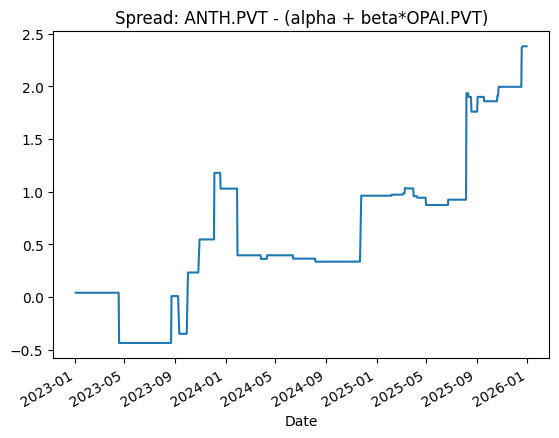

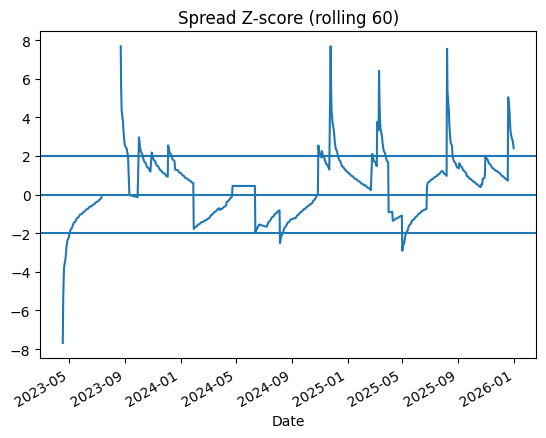

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint, adfuller
import matplotlib.pyplot as plt


def read_two_ticker_yahoo_export(path, field="Close"):
    raw = pd.read_csv(path)

    # Find the columns for the chosen field (Close, Close.1, Close.2, ...)
    field_cols = [c for c in raw.columns if c == field or c.startswith(field + ".")]
    if len(field_cols) < 2:
        raise ValueError(
            f"Expected at least 2 '{field}' columns (e.g., Close and Close.1). "
            f"Found: {field_cols}"
        )

    # Tickers are in row 0 under Close and Close.1
    tickers = [str(raw.loc[0, c]).strip() for c in field_cols[:2]]

    # Drop the ticker row and parse the time series
    df = raw.iloc[1:].copy()
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.dropna(subset=["Date"]).sort_values("Date")

    # Convert numeric
    for c in field_cols[:2]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    prices = df.set_index("Date")[field_cols[:2]].copy()
    prices.columns = tickers  # rename to actual ticker symbols
    prices = prices.replace([np.inf, -np.inf], np.nan).sort_index()

    return prices, tickers[0], tickers[1]


# 2) Align pair and basic quality checks

def align_pair(prices, min_obs=252):
    pair = prices.dropna().copy()
    pair = pair[~pair.index.duplicated(keep="first")].sort_index()
    if len(pair) < min_obs:
        raise ValueError(f"Not enough overlapping observations: {len(pair)} < {min_obs}")
    return pair



# 3) Half-life estimation
#    Δs_t = a + b*s_{t-1} + e_t  => half-life = -ln(2)/b (if b<0)

def half_life(spread: pd.Series) -> float:
    s = spread.dropna()
    if len(s) < 50:
        return np.nan

    s_lag = s.shift(1).dropna()
    ds = s.diff().dropna()
    s_lag = s_lag.loc[ds.index]

    X = sm.add_constant(s_lag.values)
    y = ds.values
    fit = sm.OLS(y, X).fit()

    b = fit.params[1]
    if b >= 0:
        return np.inf
    return float(-np.log(2) / b)


def rolling_half_life(spread: pd.Series, window: int) -> pd.Series:
    def _hl(w):
        w = pd.Series(w).dropna()
        if len(w) < 50:
            return np.nan
        return half_life(w)
    return spread.rolling(window).apply(_hl, raw=False)



# 4) Full "Is this a good pair?" evaluator
#    Uses formation-window global beta (recommended)

def evaluate_pair(
    pair_prices: pd.DataFrame,
    y_ticker: str,
    x_ticker: str,
    *,
    use_log=True,
    formation_window=252,
    coint_p_thresh=0.05,
    spread_adf_p_thresh=0.05,
    half_life_min=5,
    half_life_max=60,
    rolling_hl_window=252,
    require_abs_return_corr=0.3,     
):
    data = pair_prices[[y_ticker, x_ticker]].dropna().copy()

    # Log prices 
    if use_log:
        if (data <= 0).any().any():
            raise ValueError("Non-positive prices found; cannot log-transform.")
        P = np.log(data)
    else:
        P = data

    # Return correlation 
    rets = P.diff().dropna()
    ret_corr = float(rets[y_ticker].corr(rets[x_ticker]))

    # Formation window 
    form = P.iloc[:formation_window].copy()
    if len(form) < formation_window:
        raise ValueError(f"Need at least {formation_window} observations for formation window.")

    # (1) Cointegration test (Engle–Granger) on formation window
    coint_t, coint_p, coint_crit = coint(form[y_ticker], form[x_ticker])

    # (2) Hedge ratio estimate on formation window: y ~ alpha + beta*x
    y = form[y_ticker].values
    x = form[x_ticker].values
    X = sm.add_constant(x)
    ols = sm.OLS(y, X).fit()
    alpha = float(ols.params[0])
    beta = float(ols.params[1])

    # (3) Spread across full period with fixed alpha/beta
    spread = P[y_ticker] - (alpha + beta * P[x_ticker])
    spread.name = "spread"

    # (4) ADF on spread 
    adf_stat, adf_p, adf_lags, adf_nobs, adf_crit, *_ = adfuller(
        spread.dropna(), regression="c", autolag="AIC"
    )

    # (5) Half-life (full period)
    hl = half_life(spread)

    # (6) Rolling half-life stability 
    hl_roll = rolling_half_life(spread, rolling_hl_window)
    h = hl_roll.replace([np.inf, -np.inf], np.nan).dropna()
    hl_roll_stats = None
    if len(h) > 0:
        hl_roll_stats = {
            "window": rolling_hl_window,
            "median": float(np.median(h)),
            "iqr": float(np.percentile(h, 75) - np.percentile(h, 25)),
            "p90": float(np.percentile(h, 90)),
            "last": float(h.iloc[-1]),
            "n": int(len(h))
        }
    else:
        hl_roll_stats = {"window": rolling_hl_window, "note": "not enough rolling data"}

    # Decision rules 
    passes = {
        "abs_return_corr_screen": (abs(ret_corr) >= require_abs_return_corr) if require_abs_return_corr is not None else True,
        "cointegration": (coint_p <= coint_p_thresh),
        "spread_stationary_adf": (adf_p <= spread_adf_p_thresh),
        "half_life_in_range": (np.isfinite(hl) and (hl >= half_life_min) and (hl <= half_life_max)),
    }

    suitable = all(passes.values())

    report = {
        "pair": (y_ticker, x_ticker),
        "n_obs": int(len(P)),
        "use_log": use_log,
        "formation_window": formation_window,
        "return_corr": ret_corr,
        "alpha": alpha,
        "beta": beta,
        "cointegration_t": float(coint_t),
        "cointegration_p": float(coint_p),
        "cointegration_crit_5pct": float(coint_crit[1]),
        "spread_adf_stat": float(adf_stat),
        "spread_adf_p": float(adf_p),
        "spread_adf_crit_5pct": float(adf_crit["5%"]),
        "half_life": float(hl),
        "rolling_half_life_stats": hl_roll_stats,
        "passes": passes,
        "suitable": suitable
    }

    if not suitable:
        report["not_suitable_reasons"] = [k for k, v in passes.items() if not v]

    return suitable, report, spread



path = "data1.csv"  # in the same folder as notebook; or use full path

prices, t1, t2 = read_two_ticker_yahoo_export(path, field="Close")
print("Tickers detected:", t1, "and", t2)
print("Raw extracted prices shape:", prices.shape)

pair = align_pair(prices, min_obs=252)
print("Aligned pair shape (after dropping missing dates):", pair.shape)

suitable, report, spread = evaluate_pair(
    pair_prices=pair,
    y_ticker=t1,
    x_ticker=t2,
    use_log=True,
    formation_window=252,
    coint_p_thresh=0.05,
    spread_adf_p_thresh=0.05,
    half_life_min=5,
    half_life_max=60,
    rolling_hl_window=252,
    require_abs_return_corr=0.3,  
)

print("\n=== FINAL DECISION ===")
print("SUITABLE FOR PAIRS TRADING:", suitable)

print("\n=== REPORT ===")
for k, v in report.items():
    print(f"{k}: {v}")

# Optional: plot spread and z-score
lookback = 60
mu = spread.rolling(lookback).mean()
sd = spread.rolling(lookback).std(ddof=0)
z = (spread - mu) / sd

plt.figure()
spread.plot(title=f"Spread: {t1} - (alpha + beta*{t2})")
plt.show()

plt.figure()
z.plot(title=f"Spread Z-score (rolling {lookback})")
plt.axhline(0)
plt.axhline(2)
plt.axhline(-2)
plt.show()

In [417]:
train_end = "2023-12-31"
test_start = "2024-01-01"

train_prices = prices.loc[:train_end].copy()
test_prices  = prices.loc[test_start:].copy()

In [418]:
def load_yahoo_multiticker_close(path: str, field="Close") -> pd.DataFrame:
    raw = pd.read_csv(path)

    field_cols = [c for c in raw.columns if c == field or c.startswith(field + ".")]
    if len(field_cols) < 2:
        raise ValueError(f"Need at least 2 '{field}' columns. Found: {field_cols}")

    tickers = [str(raw.loc[0, c]).strip() for c in field_cols]

    # drop ticker row + date row
    df = raw.iloc[2:].copy()
    df["Date"] = pd.to_datetime(df["Price"], errors="coerce")
    df = df.dropna(subset=["Date"]).sort_values("Date")

    for c in field_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    prices = df.set_index("Date")[field_cols].copy()
    prices.columns = tickers
    prices = prices.replace([np.inf, -np.inf], np.nan)
    prices = prices[~prices.index.duplicated(keep="first")].sort_index()
    prices = prices.dropna(axis=1, how="all")
    return prices


In [ ]:
data3_path = "data3.csv" 
prices = load_yahoo_multiticker_close(data3_path, field="Close")

In [420]:
prices

,AMZN,ANTH.PVT,BTCB-USD,DB,DOGE-USD,ETC-USD,GOOG,ING,JEPI,JPM,KO,OPAI.PVT,PEP,UBS,WFC,XLM-USD
Date,,,,,,,,,,,,,,,,
2020-01-01,NaN,NaN,7268.917480,NaN,0.002033,4.502792,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.045451
2020-01-02,94.900497,NaN,6976.632324,7.472999,0.002009,4.255888,67.811768,8.886567,NaN,119.036446,45.745102,NaN,112.112404,10.614063,46.052406,0.044112
2020-01-03,93.748497,NaN,7368.449219,7.284605,0.002145,4.576237,67.479004,8.722134,NaN,117.465569,45.495533,NaN,111.955566,10.441544,45.769669,0.045234
2020-01-04,NaN,NaN,7436.281250,NaN,0.002241,4.726842,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.046272
2020-01-05,NaN,NaN,7411.915039,NaN,0.002419,4.907899,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.045359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27,NaN,NaN,87687.250000,NaN,0.124224,12.211022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.220622
2025-12-28,NaN,NaN,87766.296875,NaN,0.123825,12.179569,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.220068
2025-12-29,232.070007,272.980011,87153.406250,38.619999,0.122730,11.916054,314.168701,27.950001,57.215641,322.296204,70.160004,499.279999,142.962769,46.549999,94.519997,0.215940


In [421]:
maindata0 = prices


In [422]:
maindata1 = maindata0.copy()

In [423]:
maindata = maindata0.loc[:train_end].copy()

In [424]:
maindatatest = maindata1.loc[test_start:]

In [425]:
maindatatest

,AMZN,ANTH.PVT,BTCB-USD,DB,DOGE-USD,ETC-USD,GOOG,ING,JEPI,JPM,KO,OPAI.PVT,PEP,UBS,WFC,XLM-USD
Date,,,,,,,,,,,,,,,,
2024-01-01,NaN,NaN,43985.078125,NaN,0.092024,22.500179,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.131905
2024-01-02,149.929993,56.480000,44971.941406,12.866043,0.091204,22.001184,138.423553,13.019940,46.884735,163.843567,56.383640,150.000000,159.680069,28.688696,47.037601,0.129287
2024-01-03,148.470001,56.480000,42810.136719,12.610803,0.082042,20.031158,139.217026,12.931728,46.621063,163.129471,56.515598,150.000000,159.716995,27.650618,46.417805,0.120552
2024-01-04,144.570007,56.480000,44268.085938,12.875497,0.084131,20.501585,136.915939,12.737664,46.604042,164.212006,56.327084,150.000000,158.350235,27.905416,46.989925,0.121644
2024-01-05,145.240005,56.480000,44130.425781,12.979484,0.082773,20.122894,136.271225,12.817054,46.570007,165.035934,56.242260,150.000000,156.013840,28.235716,47.600182,0.119129
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27,NaN,NaN,87687.250000,NaN,0.124224,12.211022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.220622
2025-12-28,NaN,NaN,87766.296875,NaN,0.123825,12.179569,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.220068
2025-12-29,232.070007,272.980011,87153.406250,38.619999,0.122730,11.916054,314.168701,27.950001,57.215641,322.296204,70.160004,499.279999,142.962769,46.549999,94.519997,0.215940


In [426]:
# Computing half-life of the columns 
def half_life(spread: pd.Series) -> float:
    s = spread.dropna()
    #if len(s) < 60:
    #    return np.nan

    s_lag = s.shift(1).dropna()
    ds = s.diff().dropna()
    s_lag = s_lag.loc[ds.index]

    X = sm.add_constant(s_lag.values)
    y = ds.values
    fit = sm.OLS(y, X).fit()
    b = fit.params[1]

    if b >= 0:
        return np.inf
    return float(-np.log(2) / b)


In [427]:
list_halflife = []
for column in maindata:
    list_halflife.append(half_life(maindata[column]))
    print(column, half_life(maindata[column]))   



AMZN 93.59484467867334
ANTH.PVT inf
BTCB-USD 181.8170734318205
DB 70.68456328586113
DOGE-USD 67.8471311015057
ETC-USD 69.24144339750104
GOOG 170.86144547566775
ING 380.23188987069943
JEPI 150.8987285808984
JPM 208.50620582010689
KO 136.43542719697965
OPAI.PVT 115.61202471064315
PEP 154.5973164977931
UBS inf
WFC 128.51712856807868
XLM-USD 99.24032787064817


In [428]:
maindata_0 = maindata.drop(['ANTH.PVT', 'DB', 'GOOG', 'ING', 'JPM', 'OPAI.PVT', 'UBS', 'WFC'], axis = 1)
maindata_0

,AMZN,BTCB-USD,DOGE-USD,ETC-USD,JEPI,KO,PEP,XLM-USD
Date,,,,,,,,
2020-01-01,NaN,7268.917480,0.002033,4.502792,NaN,NaN,NaN,0.045451
2020-01-02,94.900497,6976.632324,0.002009,4.255888,NaN,45.745102,112.112404,0.044112
2020-01-03,93.748497,7368.449219,0.002145,4.576237,NaN,45.495533,111.955566,0.045234
2020-01-04,NaN,7436.281250,0.002241,4.726842,NaN,NaN,NaN,0.046272
2020-01-05,NaN,7411.915039,0.002419,4.907899,NaN,NaN,NaN,0.045359
...,...,...,...,...,...,...,...,...
2023-12-27,153.339996,43481.109375,0.093579,22.690660,46.699303,55.337406,156.438629,0.130853
2023-12-28,153.380005,42584.824219,0.091884,22.497866,46.765636,55.375111,156.429382,0.132362
2023-12-29,151.940002,42054.777344,0.091038,22.459976,46.765636,55.544769,156.844971,0.129619


In [ ]:
# Rolling half-life for the columns
def rolling_half_life(spread: pd.Series, window: int) -> pd.Series:
    return spread.rolling(window).apply(half_life, raw=False)

In [430]:
list_rollinghalflife = []
for column in maindata:
    list_rollinghalflife.append(rolling_half_life(maindata[column], 230))
    print(column, rolling_half_life(maindata[column], 230).min())   
df_rollinghalflife = pd.DataFrame(list_rollinghalflife)


AMZN nan
ANTH.PVT nan
BTCB-USD 10.005589839464902
DB nan
DOGE-USD 6.654596142406773
ETC-USD 6.220435273228179
GOOG nan
ING nan
JEPI nan
JPM nan
KO nan
OPAI.PVT nan
PEP nan
UBS nan
WFC nan
XLM-USD 4.836710953849948


In [431]:
df_rollinghalflife

Date,2020-01-01,2020-01-02,2020-01-03,2020-01-04,2020-01-05,2020-01-06,2020-01-07,2020-01-08,2020-01-09,2020-01-10,2020-01-11,2020-01-12,2020-01-13,2020-01-14,2020-01-15,2020-01-16,2020-01-17,2020-01-18,2020-01-19,2020-01-20,2020-01-21,2020-01-22,2020-01-23,2020-01-24,2020-01-25,2020-01-26,2020-01-27,2020-01-28,2020-01-29,2020-01-30,2020-01-31,2020-02-01,2020-02-02,2020-02-03,2020-02-04,2020-02-05,2020-02-06,2020-02-07,2020-02-08,2020-02-09,2020-02-10,2020-02-11,...,2023-11-20,2023-11-21,2023-11-22,2023-11-23,2023-11-24,2023-11-25,2023-11-26,2023-11-27,2023-11-28,2023-11-29,2023-11-30,2023-12-01,2023-12-02,2023-12-03,2023-12-04,2023-12-05,2023-12-06,2023-12-07,2023-12-08,2023-12-09,2023-12-10,2023-12-11,2023-12-12,2023-12-13,2023-12-14,2023-12-15,2023-12-16,2023-12-17,2023-12-18,2023-12-19,2023-12-20,2023-12-21,2023-12-22,2023-12-23,2023-12-24,2023-12-25,2023-12-26,2023-12-27,2023-12-28,2023-12-29,2023-12-30,2023-12-31
AMZN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ANTH.PVT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BTCB-USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,412.729128,82.376271,215.427100,185.911571,347.867151,543.544109,248.682092,190.188974,410.199517,356.557894,326.403152,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
DB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DOGE-USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,13.503551,15.702360,16.925357,17.255143,16.850902,16.265009,16.286057,16.488585,15.350635,14.426142,14.804115,14.026972,14.086391,12.442111,19.574742,28.577502,44.171371,48.462634,480.942385,85.923509,327.482870,42.393645,39.515311,51.220871,62.368138,38.983054,58.129109,40.444341,37.639213,35.735276,36.918329,52.353720,54.795705,53.016389,47.428158,57.567917,46.631622,54.241064,49.035885,47.224342,45.548106,44.489405
ETC-USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,17.404161,16.805456,17.144220,17.131690,16.912721,16.362008,15.142547,13.992152,12.970299,12.541870,12.591659,12.136845,12.927731,12.579788,15.226934,15.970757,17.127865,19.508649,22.356725,22.618287,21.873895,17.060235,16.903486,17.719323,18.081601,16.773179,18.256402,16.975161,16.646368,16.652620,16.947391,18.532600,21.974138,21.286064,19.593754,21.165465,20.292217,25.955725,25.591875,25.985811,25.545733,24.392037
GOOG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ING,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

In [432]:
rollingwindowcolumns = ['BTCB-USD','DOGE-USD', 'ETC-USD','XLM-USD']
maindata_1 = maindata.copy()
for column in maindata_1.columns:
    if column not in rollingwindowcolumns:
        maindata_1.drop(column, axis = 1, inplace= True)

       

In [434]:
# ADF p-value 
def adf_pvalue(spread: pd.Series,  regression="c") -> pd.Series:
    return float(adfuller(spread, regression=regression, autolag="AIC")[1])


In [435]:
# Rolling ADF p-value
def rolling_adf_pvalue(spread: pd.Series, window: int, regression="c") -> pd.Series:
    def _adf_p(w):
        w = pd.Series(w).dropna()
        if len(w) < window:
            return np.nan
        try:
            return float(adfuller(w, regression=regression, autolag="AIC")[1])
        except Exception:
            return np.nan

    return spread.rolling(window).apply(_adf_p, raw=False)

In [436]:
listofadf_pvalue = []
for column in maindata:
    listofadf_pvalue.append(adf_pvalue((maindata[column].dropna())))
    print(column, adf_pvalue(maindata[column].dropna()))   


AMZN 0.2514099990897516
ANTH.PVT 0.9909941731114992
BTCB-USD 0.4003924660568195
DB 0.07859961978156778
DOGE-USD 0.14664614287568745
ETC-USD 0.13128439565789313
GOOG 0.5278918446199967
ING 0.6972897194688608
JEPI 0.29660331135552087
JPM 0.773337624256228
KO 0.5389805136130177
OPAI.PVT 0.8995028741819108
PEP 0.5655385053966765
UBS 0.9906801870673477
WFC 0.44207835474339985
XLM-USD 0.34526951087030655


In [437]:
listofrolladf_pvalue = []
for column in maindata_1:
    listofrolladf_pvalue.append(adf_pvalue((maindata_1[column])))
    print(column, adf_pvalue(maindata_1[column]))   

BTCB-USD 0.4003924660568195
DOGE-USD 0.14664614287568745
ETC-USD 0.13128439565789313
XLM-USD 0.34526951087030655


In [ ]:
# Evaluate a pair with global beta and filters 
def evaluate_pair_with_stability(
    prices: pd.DataFrame,
    y_ticker: str,
    x_ticker: str,
    *,
    use_log=True,
    min_obs=252,
    formation_window=230,

    # base filters
    coint_p_thresh=0.09,
    spread_adf_p_thresh=0.09,
    half_life_min=5,
    half_life_max=230,
):
    # Align pair
    data = prices[[y_ticker, x_ticker]].dropna().copy()
    if len(data) < min_obs:
        raise ValueError(f"Not enough overlap: {len(data)} < {min_obs}")

    # log transform
    if use_log:
        if (data <= 0).any().any():
            raise ValueError("Non-positive prices found; cannot take logs.")
        P = np.log(data)
    else:
        P = data

    # return corr (screen)
    returns = P.diff().dropna()
    returns_corr = float(returns[y_ticker].corr(returns[x_ticker]))

    # cointegration test on formation
    coint_t, coint_p, coint_crit = coint(P[y_ticker], P[x_ticker])

    # hedge ratio on formation: y ~ alpha + beta*x
    y = P[y_ticker].values
    x = P[x_ticker].values
    X = sm.add_constant(x)
    ols = sm.OLS(y, X).fit()
    alpha = float(ols.params[0])
    beta  = float(ols.params[1])

    # spread on full aligned sample
    spread = P[y_ticker] - (alpha + beta * P[x_ticker])
    spread.name = "spread"

    # ADF on full spread
    adf_stat, adf_p, adf_lags, adf_nobs, adf_crit, *_ = adfuller(
        spread.dropna(), regression="c", autolag="AIC"
    )

    # Half-life on full spread
    hl = half_life(spread)


    adf_p = adf_pvalue(spread, regression="c")
    _hl = half_life(spread)

    passes = {}

    passes["cointegration"] = (coint_p <= coint_p_thresh)
    passes["spread_adf_full"] = (adf_p <= spread_adf_p_thresh)
    passes["half_life_full_fast"] = (np.isfinite(hl) and (hl >= half_life_min) and (hl <= half_life_max))

    suitable = all(passes.values())

    report = {
        "y": y_ticker,
        "x": x_ticker,
        "n_obs": int(len(P)),
        "return_corr": returns_corr,
        "alpha": alpha,
        "beta": beta,
        "coint_p": float(coint_p),
        "spread_adf_p": float(adf_p),
        "half_life": float(hl),
        "suitable": bool(suitable),
        "fails": ",".join([k for k, v in passes.items() if not v]) if not suitable else ""
    }

    diagnostics = {"spread": spread, "adf_p": adf_p, "_hl": _hl}
    return report, diagnostics



In [439]:
tickers = maindata.columns

In [ ]:
import itertools

prices = maindata
results = []
diag_store = {}  # store diagnostics for top plots

MIN_OBS = 252  # set minimum overlap for pairs

for y_ticker, x_ticker in itertools.combinations(tickers, 2):
    # quick overlap check first (fast)
    pair = prices[[y_ticker, x_ticker]].dropna()
    if len(pair) < MIN_OBS:
        continue

    try:
        rep, diag = evaluate_pair_with_stability(
            prices=prices,
            y_ticker=y_ticker,
            x_ticker=x_ticker,
            use_log=True,
            min_obs=MIN_OBS,

            coint_p_thresh=0.09,
            spread_adf_p_thresh=0.09,
            half_life_min=5,
            half_life_max=160,
        )
        results.append(rep)

        # store diagnostics only for suitable pairs (or store later for top N)
        if rep["suitable"]:
            diag_store[(rep["y"], rep["x"])] = diag

    except Exception as e:
        results.append({
            "y": y_ticker, "x": x_ticker, "suitable": False,
            "error": str(e)
        })

results_df = pd.DataFrame(results)

# Candidates
candidates_df = (results_df
                 .query("suitable == True")
                 .sort_values(["coint_p", "spread_adf_p", "half_life"],
                              ascending=[True, True, True]))

print("\nTop candidates:")
display(candidates_df.head(20))

# Save
results_df.to_csv("pair_screen_results_with_stability_new.csv", index=False)
candidates_df.to_csv("pair_screen_candidates_with_stability_new.csv", index=False)
print("\nSaved CSVs:",
      "pair_screen_results_with_stability_new.csv",
      "pair_screen_candidates_with_stability_new.csv")



Top candidates:


,y,x,n_obs,return_corr,alpha,beta,coint_p,spread_adf_p,half_life,suitable,fails
44,DOGE-USD,WFC,1006,0.141315,-22.803970,5.471984,0.001555,0.000231,29.845486,True,
53,ETC-USD,WFC,1006,0.196775,-5.917657,2.458175,0.004363,0.000764,26.522093,True,
30,DB,JPM,1006,0.659664,-1.774821,0.847389,0.015625,0.003442,28.876968,True,
27,DB,GOOG,1006,0.366497,-0.370960,0.568310,0.016434,0.003654,35.975963,True,
61,GOOG,WFC,1006,0.412781,1.976335,0.746323,0.020189,0.004608,46.309749,True,
57,GOOG,JPM,1006,0.443775,-0.527155,1.084088,0.020246,0.004634,35.108930,True,
19,BTCB-USD,JPM,1006,0.284884,-2.294951,2.597907,0.031339,0.007447,27.629228,True,
81,KO,PEP,1006,0.779459,-0.193429,0.832146,0.042194,0.010763,32.993589,True,
13,BTCB-USD,DB,1006,0.304746,4.498693,2.470239,0.043422,0.011290,33.599941,True,
55,GOOG,ING,1006,0.392230,3.290288,0.636969,0.045934,0.012055,47.110408,True,



Saved CSVs: pair_screen_results_with_stability_new.csv pair_screen_candidates_with_stability_new.csv


In [ ]:
# Evaluate a pair with global beta and filters but with rolling windows
def evaluate_pair_with_stability(
    prices: pd.DataFrame,
    y_ticker: str,
    x_ticker: str,
    *,
    use_log=True,
    min_obs=252,
    formation_window=252,

    # base filters
    coint_p_thresh=0.09,
    spread_adf_p_thresh=0.09,
    half_life_min=5,
    half_life_max=70,
    

    # rolling stability settings
    roll_window=72,
    roll_step=1,  
    roll_adf_p_thresh=0.09,
    roll_adf_pass_frac_min=0.60,  # e.g. >=70% of rolling windows pass ADF
    roll_hl_finite_frac_min=0.60, # e.g. >=80% finite HL in rolling windows
    roll_hl_median_max=60,        # median rolling HL must be <= this
    roll_hl_iqr_max=60            # IQR threshold to avoid "jumpy" HL
):
    # Align pair
    data = prices[[y_ticker, x_ticker]].dropna().copy()
    if len(data) < min_obs:
        raise ValueError(f"Not enough overlap: {len(data)} < {min_obs}")

    # log transform
    if use_log:
        if (data <= 0).any().any():
            raise ValueError("Non-positive prices found; cannot take logs.")
        P = np.log(data)
    else:
        P = data

    # return corr (screen)
    rets = P.diff().dropna()
    ret_corr = float(rets[y_ticker].corr(rets[x_ticker]))

    # formation window
    if len(P) < formation_window:
        raise ValueError(f"Need at least {formation_window} observations.")
    form = P.iloc[:formation_window]

    # cointegration test on formation
    coint_t, coint_p, coint_crit = coint(form[y_ticker], form[x_ticker])

    # hedge ratio on formation: y ~ alpha + beta*x
    y = form[y_ticker].values
    x = form[x_ticker].values
    X = sm.add_constant(x)
    ols = sm.OLS(y, X).fit()
    alpha = float(ols.params[0])
    beta  = float(ols.params[1])

    # spread on full aligned sample
    spread = P[y_ticker] - (alpha + beta * P[x_ticker])
    spread.name = "spread"

    # ADF on full spread
    adf_stat, adf_p, adf_lags, adf_nobs, adf_crit, *_ = adfuller(
        spread.dropna(), regression="c", autolag="AIC"
    )

    # Half-life on full spread
    hl = half_life(spread)

    if len(spread.dropna()) < roll_window:
        raise ValueError(f"Not enough data for rolling window {roll_window}.")

    roll_adf_p = rolling_adf_pvalue(spread, roll_window, regression="c")
    roll_hl = rolling_half_life(spread, roll_window)

    # Optionally downsample rolling series for speed (keep step=1 by default)
    if roll_step > 1:
        roll_adf_p = roll_adf_p.iloc[::roll_step]
        roll_hl = roll_hl.iloc[::roll_step]

    # Rolling ADF pass fraction
    adf_valid = roll_adf_p.dropna()
    adf_pass_frac = float((adf_valid <= roll_adf_p_thresh).mean()) if len(adf_valid) else np.nan

    # Rolling HL stability: finite fraction + median + IQR
    hl_valid = roll_hl.replace([np.inf, -np.inf], np.nan).dropna()
    hl_finite_frac = float(hl_valid.notna().mean()) if len(roll_hl.dropna()) else np.nan
    hl_median = float(np.median(hl_valid)) if len(hl_valid) else np.nan
    hl_iqr = float(np.percentile(hl_valid, 75) - np.percentile(hl_valid, 25)) if len(hl_valid) else np.nan

  
    # Decision rules
   
    passes = {}

    # classic filters
    passes["cointegration"] = (coint_p <= coint_p_thresh)
    passes["spread_adf_full"] = (adf_p <= spread_adf_p_thresh)
    passes["half_life_full_range"] = (np.isfinite(hl) and (hl >= half_life_min) and (hl <= half_life_max))

    # stability filters
    passes["rolling_adf_stable"] = (np.isfinite(adf_pass_frac) and adf_pass_frac >= roll_adf_pass_frac_min)
    passes["rolling_hl_finite"] = (np.isfinite(hl_finite_frac) and hl_finite_frac >= roll_hl_finite_frac_min)
    passes["rolling_hl_median_ok"] = (np.isfinite(hl_median) and hl_median <= roll_hl_median_max)
    passes["rolling_hl_iqr_ok"] = (np.isfinite(hl_iqr) and hl_iqr <= roll_hl_iqr_max)

    suitable = all(passes.values())

    report = {
        "y": y_ticker,
        "x": x_ticker,
        "n_obs": int(len(P)),
        "return_corr": ret_corr,
        "alpha": alpha,
        "beta": beta,
        "coint_p": float(coint_p),
        "coint_t": float(coint_t),
        "spread_adf_p": float(adf_p),
        "spread_adf_stat": float(adf_stat),
        "half_life": float(hl),
        "roll_window": roll_window,
        "roll_adf_pass_frac": adf_pass_frac,
        "roll_hl_finite_frac": hl_finite_frac,
        "roll_hl_median": hl_median,
        "roll_hl_iqr": hl_iqr,
        "suitable": bool(suitable),
        "fails": ",".join([k for k, v in passes.items() if not v]) if not suitable else ""
    }

    # return rolling series too for plotting top candidates
    diagnostics = {
        "spread": spread,
        "roll_adf_p": roll_adf_p,
        "roll_hl": roll_hl,
    }

    return report, diagnostics




In [ ]:
pairs_path = "data3.csv"
pairs_df = pd.read_csv(pairs_path)

if "suitable" in pairs_df.columns:
    true_pairs = pairs_df[pairs_df["suitable"] == True].copy()
else:
    true_pairs = pairs_df.copy()


assert "y" in true_pairs.columns and "x" in true_pairs.columns, f"Need columns y and x. Found: {true_pairs.columns.tolist()}"

print("Number of true pairs:", len(true_pairs))
display(true_pairs.head(10))

Number of true pairs: 15


,y,x,n_obs,return_corr,alpha,beta,coint_p,spread_adf_p,half_life,suitable,fails
13,BTCB-USD,DB,1006,0.304746,4.498693,2.470239,0.043422,0.011290,33.599941,True,NaN
16,BTCB-USD,GOOG,1006,0.310394,0.241878,2.122439,0.069979,0.020090,35.565613,True,NaN
17,BTCB-USD,ING,1006,0.309513,7.229596,1.349920,0.077693,0.022745,58.024621,True,NaN
19,BTCB-USD,JPM,1006,0.284884,-2.294951,2.597907,0.031339,0.007447,27.629228,True,NaN
25,DB,DOGE-USD,1006,0.160447,2.533637,0.081827,0.048100,0.012918,35.942821,True,NaN
27,DB,GOOG,1006,0.366497,-0.370960,0.568310,0.016434,0.003654,35.975963,True,NaN
28,DB,ING,1006,0.768668,1.246299,0.480462,0.079498,0.023299,45.255220,True,NaN
30,DB,JPM,1006,0.659664,-1.774821,0.847389,0.015625,0.003442,28.876968,True,NaN
38,DOGE-USD,ING,1006,0.144059,-12.045283,4.142752,0.085873,0.024882,54.533357,True,NaN
44,DOGE-USD,WFC,1006,0.141315,-22.803970,5.471984,0.001555,0.000231,29.845486,True,NaN


In [ ]:
def load_yahoo_multiticker_close(path: str, field="Close") -> pd.DataFrame:
    raw = pd.read_csv(path)

    field_cols = [c for c in raw.columns if c == field or c.startswith(field + ".")]
    if len(field_cols) < 2:
        raise ValueError(f"Need at least 2 '{field}' columns. Found: {field_cols}")

    tickers = [str(raw.loc[0, c]).strip() for c in field_cols]

    # drop ticker row + date row
    df = raw.iloc[2:].copy()
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.dropna(subset=["Date"]).sort_values("Date")

    for c in field_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    prices = df.set_index("Date")[field_cols].copy()
    prices.columns = tickers
    prices = prices.replace([np.inf, -np.inf], np.nan)
    prices = prices[~prices.index.duplicated(keep="first")].sort_index()
    prices = prices.dropna(axis=1, how="all")
    return prices

# If you want to load from your main dataset file:
data3_path = "data3.csv" 
prices = load_yahoo_multiticker_close(data3_path, field="Close")
prices

,AMZN,DB,GOOG,ING,JPM,KO,PEP,UBS,WFC
Date,,,,,,,,,
2020-01-03,93.748497,7.284605,67.479004,8.722134,117.465569,45.495533,111.955566,10.441544,45.769669
2020-01-06,95.143997,7.230778,69.142838,8.714984,117.372185,45.478901,112.384773,10.416899,45.495487
2020-01-07,95.343002,7.401229,69.099701,8.729283,115.376770,45.129520,110.618332,10.630494,45.118511
2020-01-08,94.598503,7.688307,69.644234,8.822225,116.276833,45.212700,111.187889,10.770153,45.255585
2020-01-09,95.052498,7.724193,70.413406,8.757882,116.701385,46.036266,111.262199,10.794800,45.178467
...,...,...,...,...,...,...,...,...,...
2025-12-24,232.380005,39.520000,315.447784,28.260000,327.691864,70.110001,142.467194,47.209999,95.300003
2025-12-26,232.520004,39.660000,314.738251,28.309999,326.437531,69.870003,142.506836,47.270000,95.260002
2025-12-29,232.070007,38.619999,314.168701,27.950001,322.296204,70.160004,142.962769,46.549999,94.519997


In [445]:

def fit_pair_model(train_prices: pd.DataFrame, y: str, x: str, use_log=True):
    pair = train_prices[[y, x]].dropna().copy()

    if use_log:
        if (pair <= 0).any().any():
            raise ValueError("Non-positive prices found; cannot take logs.")
        P = np.log(pair)
    else:
        P = pair

    X = sm.add_constant(P[x].values)
    ols = sm.OLS(P[y].values, X).fit()

    alpha = float(ols.params[0])
    beta = float(ols.params[1])

    return {
        "y": y,
        "x": x,
        "alpha": alpha,
        "beta": beta,
        "use_log": use_log,
    }

def compute_spread_from_model(prices: pd.DataFrame, model: dict):
    y = model["y"]
    x = model["x"]
    alpha = model["alpha"]
    beta = model["beta"]
    use_log = model["use_log"]

    pair = prices[[y, x]].dropna().copy()

    if use_log:
        if (pair <= 0).any().any():
            raise ValueError("Non-positive prices found; cannot take logs.")
        P = np.log(pair)
    else:
        P = pair

    spread = P[y] - (alpha + beta * P[x])
    spread.name = "spread"
    return spread

In [446]:
alpha = fit_pair_model(maindata, y, x)['alpha']

beta = fit_pair_model(maindata, y, x)['beta']
alpha , beta

(-22.803970157779286, 5.471983756633369)


=== Pair 13: BTCB-USD vs DB ===


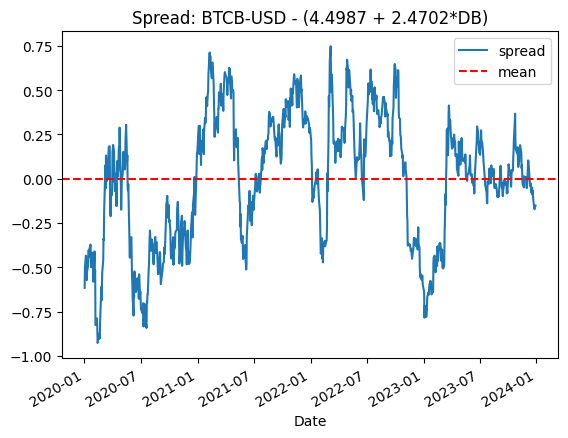

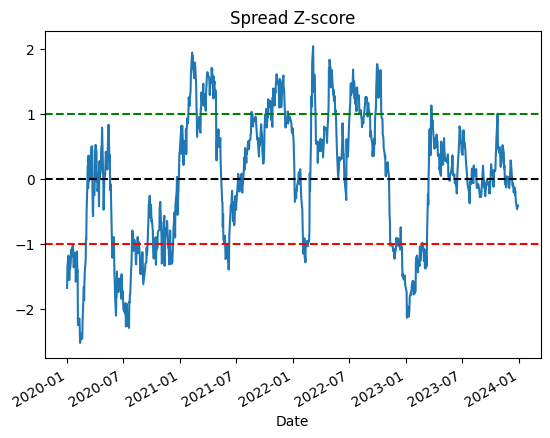


=== Pair 16: BTCB-USD vs GOOG ===


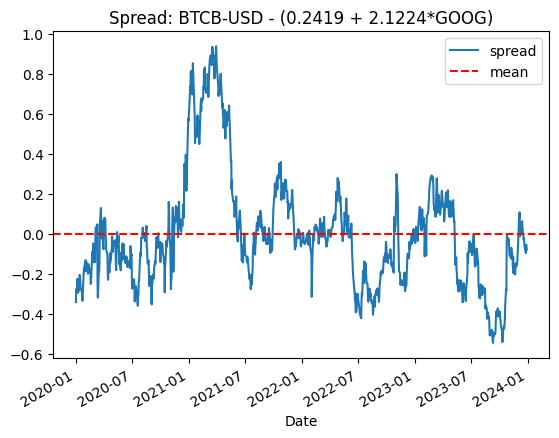

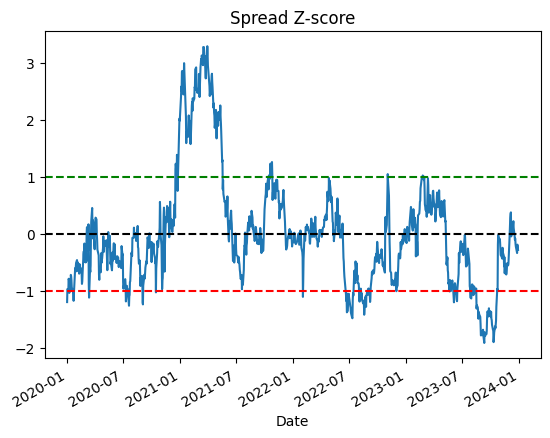


=== Pair 17: BTCB-USD vs ING ===


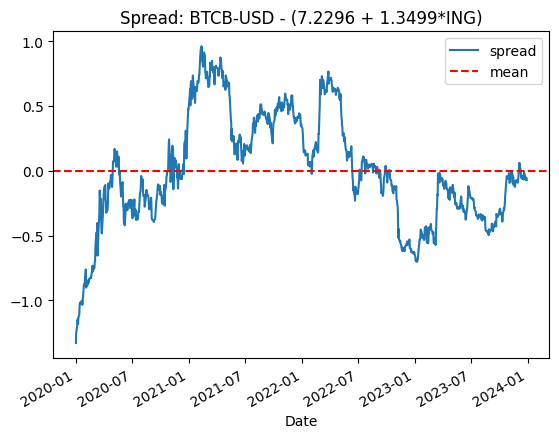

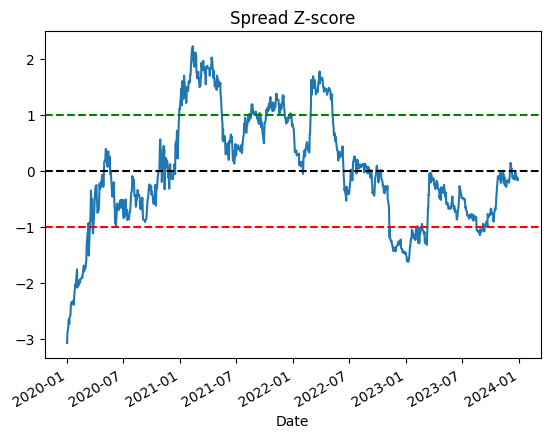


=== Pair 19: BTCB-USD vs JPM ===


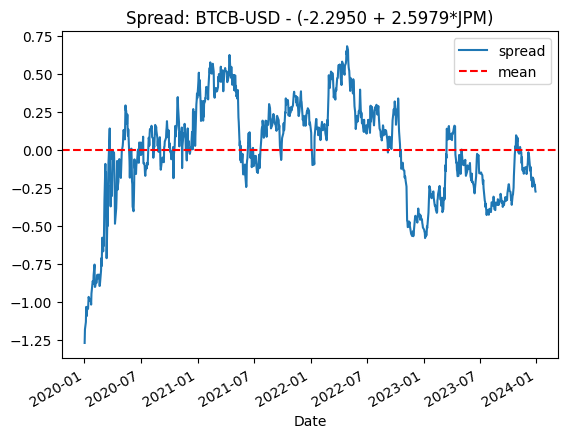

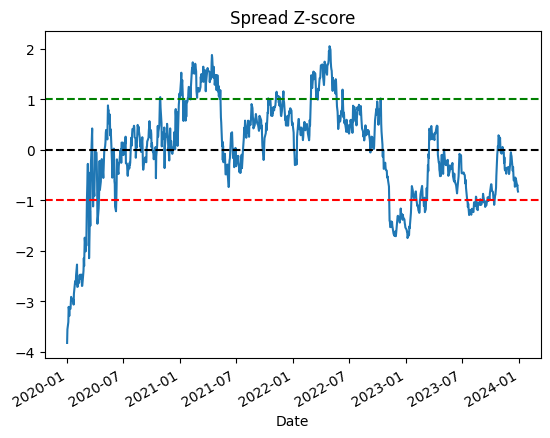


=== Pair 25: DB vs DOGE-USD ===


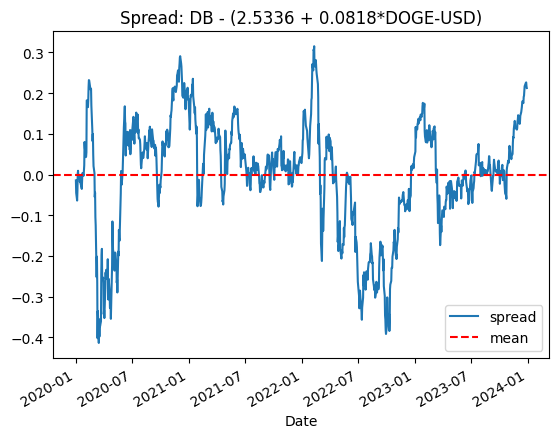

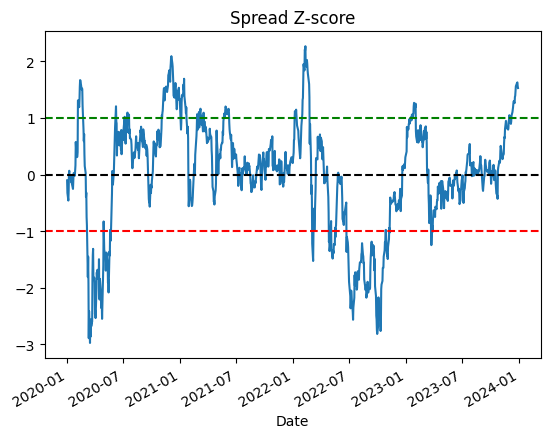


=== Pair 27: DB vs GOOG ===


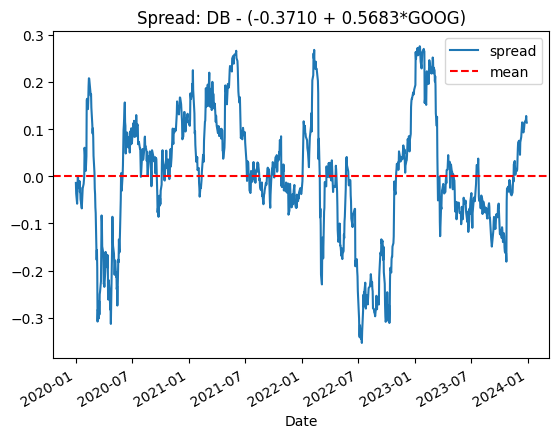

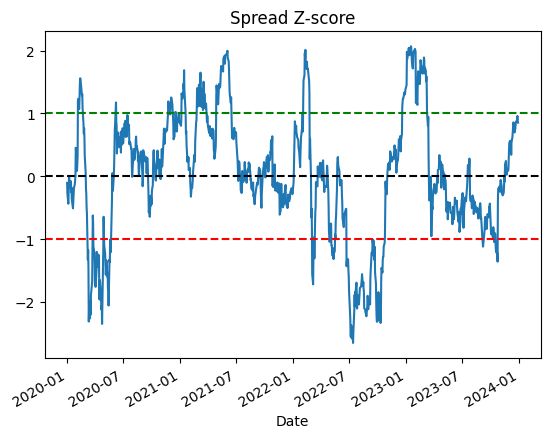


=== Pair 28: DB vs ING ===


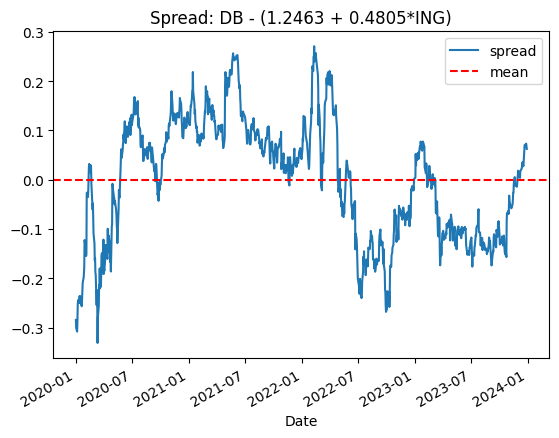

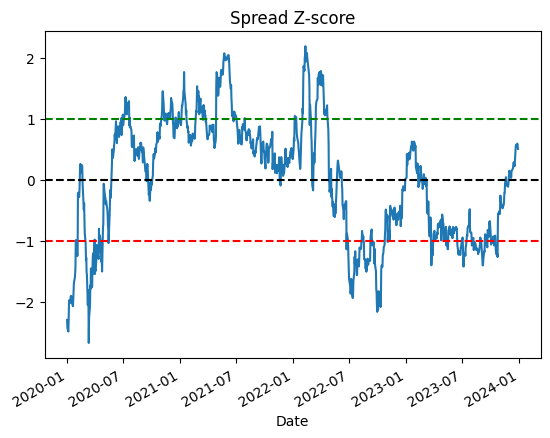


=== Pair 30: DB vs JPM ===


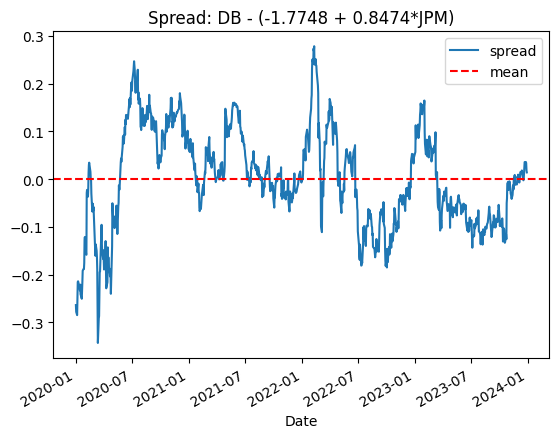

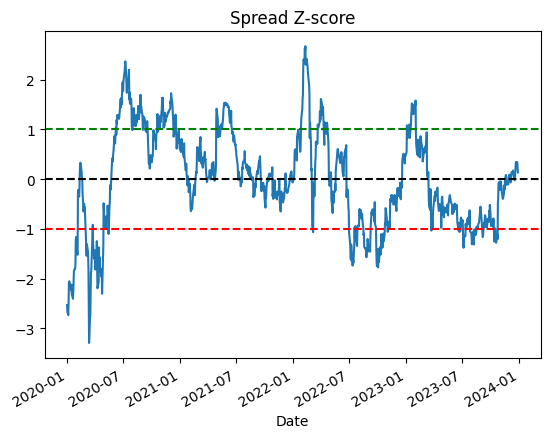


=== Pair 38: DOGE-USD vs ING ===


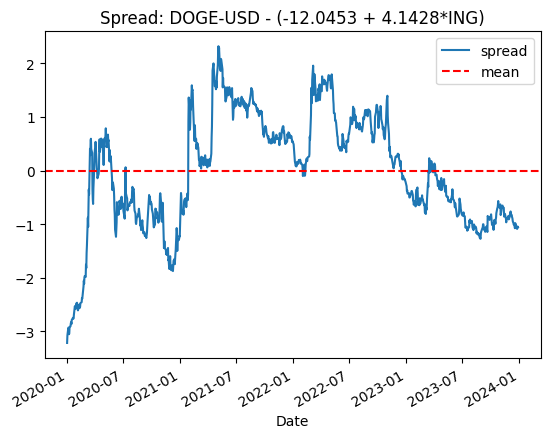

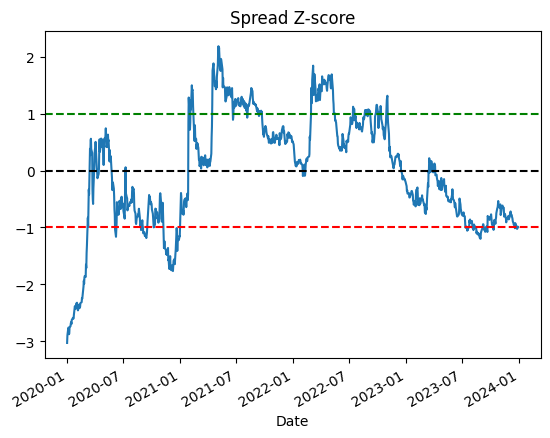


=== Pair 44: DOGE-USD vs WFC ===


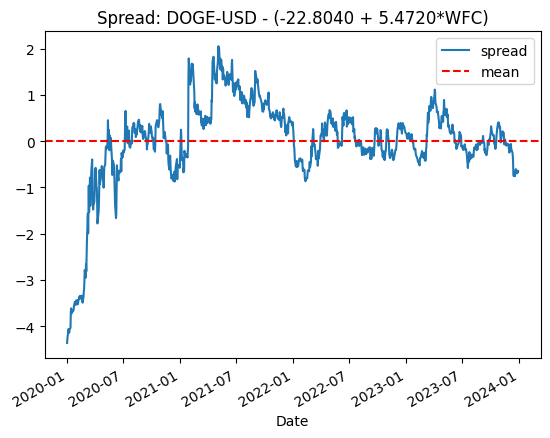

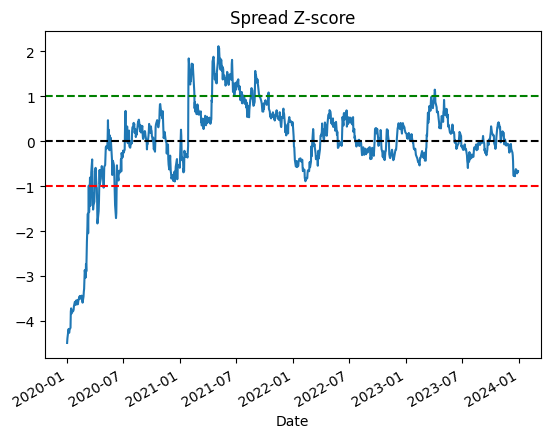

In [ ]:

#  Plot z-score for visual check

def plot_spread_and_z(spread: pd.Series, y: str, x: str, alpha: float, beta: float):
    s = spread.dropna()

    # Rolling mean line helps you see "reversion back to mean"
    s_mean = s.mean()

    # Z-score
    mu = s.mean()
    sd = s.std(ddof=0)
    z = (s - mu) / sd

    plt.figure()
    s.plot(title=f"Spread: {y} - ({alpha:.4f} + {beta:.4f}*{x})")
    plt.axhline(s_mean, color = 'red', linestyle= '--', label = 'mean')
    plt.legend()
    plt.show()


    # --- Z-score plot ---
    plt.figure()
    z.plot(title="Spread Z-score")
    plt.axhline(0, color="black", linestyle='--', label="Baseline")
    plt.axhline(1.0, color="green", linestyle='--', label="Upper Threshold (1.0)")
    plt.axhline(-1.0, color="red", linestyle='--', label="Lower Threshold (-1.0)")
    plt.show()



# E) Loop through true pairs and plot

FORMATION = 72   
TOP_N = 10         

for i, row in true_pairs.head(TOP_N).iterrows():
    y, x = row["y"], row["x"]
    model = fit_pair_model(maindata, y, x, use_log=True)
    print(f"\n=== Pair {i}: {y} vs {x} ===")
    try:
        alpha = fit_pair_model(maindata, y, x)['alpha']
        beta = fit_pair_model(maindata, y, x)['beta']
        spread = compute_spread_from_model(maindata, model)
        plot_spread_and_z(spread, y, x, alpha, beta)
    except Exception as e:
        print("Skipped due to error:", e)

In [ ]:
def generate_signals_from_z(z: pd.Series, entry_threshold=2, exit_threshold=0):
    """
    Generate long/short signals based on z-score crossing defined thresholds.
    
    Args:
    - z: Z-score series (pd.Series)
    - entry_threshold: threshold for entering trades 
    - exit_threshold: threshold for exiting trades 
    
    Returns:
    - signals: pandas Series with 1 for buy, -1 for sell, 0 for no action
    """
    signals = pd.Series(0, index=z.index)  # Initialize with 0 (no action)
    
    # Long entry signal (when z-score crosses below -1)
    signals[z < -entry_threshold] = 1  
    
    # Short entry signal (when z-score crosses above +1)
    signals[z > entry_threshold] = -1  
    
    # Exit signal: exit if z crosses back to 0 (mean reversion)
    signals[z >= exit_threshold] = 0  
    
    # Clean signals: Make sure we don't hold positions if there are no more trades
    signals = signals.diff().shift(-1).fillna(0)  # Shift for clean exit at next step

    return signals

In [471]:
# Define a function that generates signals and plots them along with spread and z-score
def plot_signals_with_z(spread, z, alpha, beta, z_lookback=60, entry_threshold=2, exit_threshold=0):
    """
    Generate signals and plot spread, z-score, and entry/exit signals.
    """
    # Generate trading signals
    signals = generate_signals_from_z(z, entry_threshold, exit_threshold)

    # --- Plot Spread ---
    plt.figure(figsize=(12, 6))
    spread.plot(title=f"Spread: {y} - ({alpha:.4f} + {beta:.4f} * {x})")
    plt.axhline(spread.mean(), linestyle="--", label="Mean")
    plt.scatter(spread.index[signals == 1], spread[signals == 1], marker='^', color='g', label="Long Signal")
    plt.scatter(spread.index[signals == -1], spread[signals == -1], marker='v', color='r', label="Short Signal")
    plt.legend()
    plt.show()

    # --- Plot Z-score ---
    plt.figure(figsize=(12, 6))
    z.plot(title=f"Spread Z-score (Lookback={z_lookback}) | {y} vs {x}")
    plt.axhline(0, color='black', linestyle='--')
    plt.axhline(entry_threshold, color='r', linestyle="--", label="Entry Threshold")
    plt.axhline(-entry_threshold, color='g', linestyle="--", label="Entry Threshold")
    plt.scatter(z.index[signals == 1], z[signals == 1], marker='^', color='g', label="Long Signal")
    plt.scatter(z.index[signals == -1], z[signals == -1], marker='v', color='r', label="Short Signal")
    plt.legend()
    plt.show()

    return signals

In [472]:
model = fit_pair_model(maindata, 'DOGE-USD', 'WFC', use_log=True)
spread = compute_spread_from_model(maindatatest,model)
spread

Date
2024-01-02   -0.663007
2024-01-03   -0.696293
2024-01-04   -0.738182
2024-01-05   -0.825062
2024-01-08   -0.842157
                ...   
2025-12-24   -4.183709
2025-12-26   -4.233354
2025-12-29   -4.184820
2025-12-30   -4.168211
2025-12-31   -4.153167
Name: spread, Length: 502, dtype: float64


=== Pair BTCB-USD vs DB ===


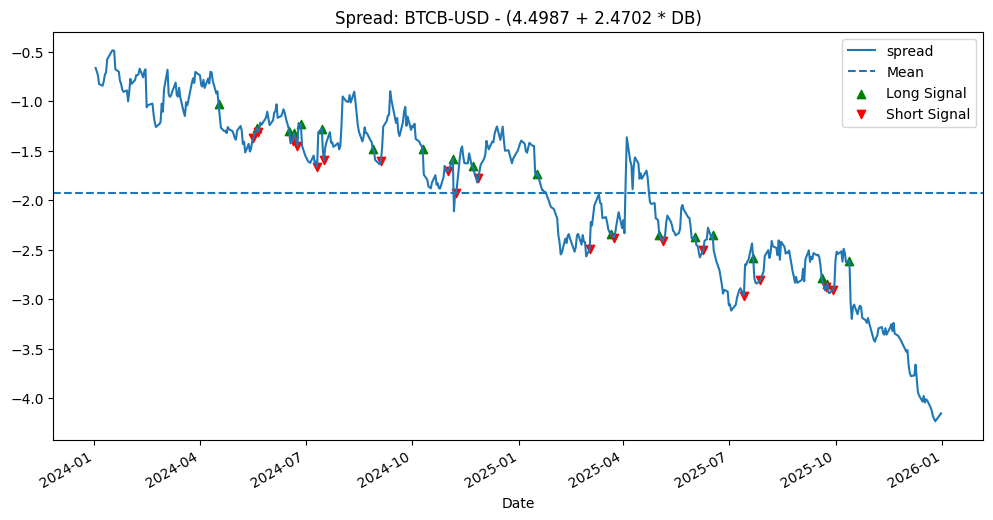

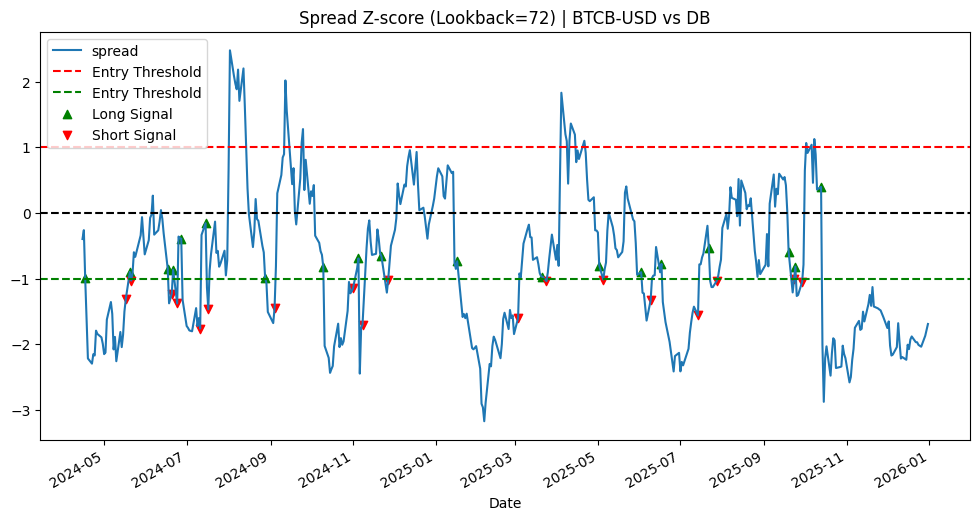


=== Pair BTCB-USD vs GOOG ===


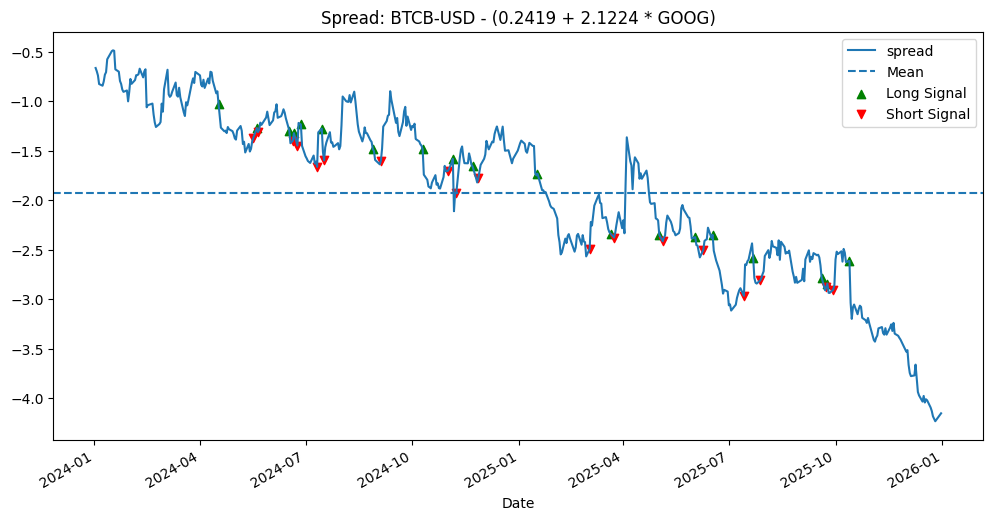

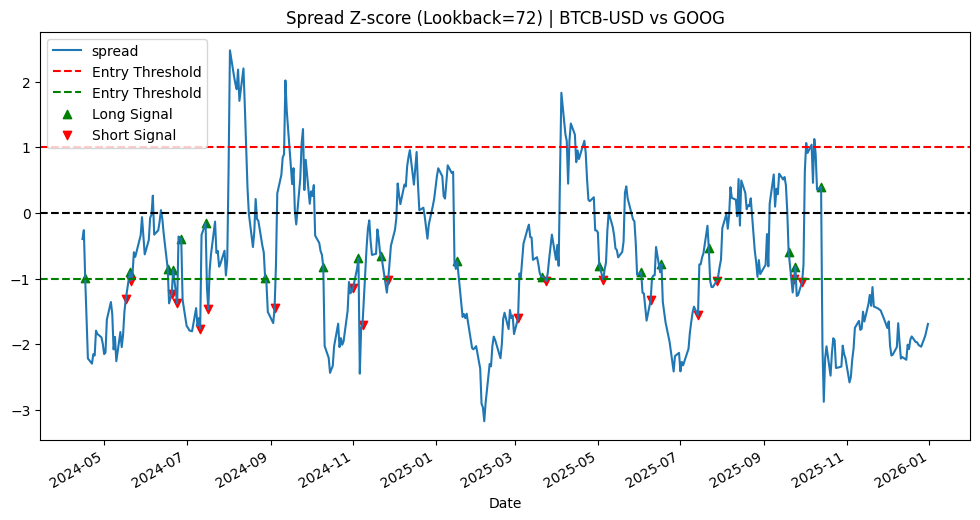


=== Pair BTCB-USD vs ING ===


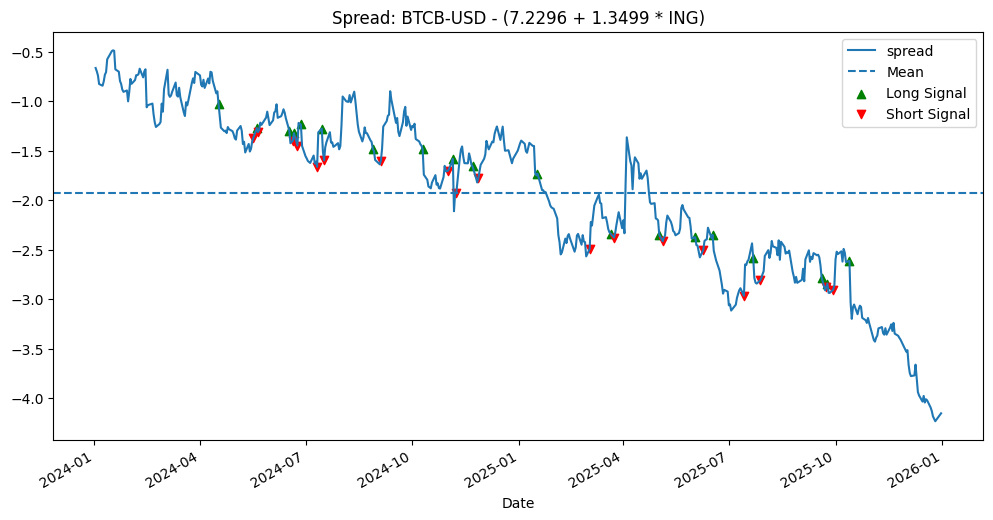

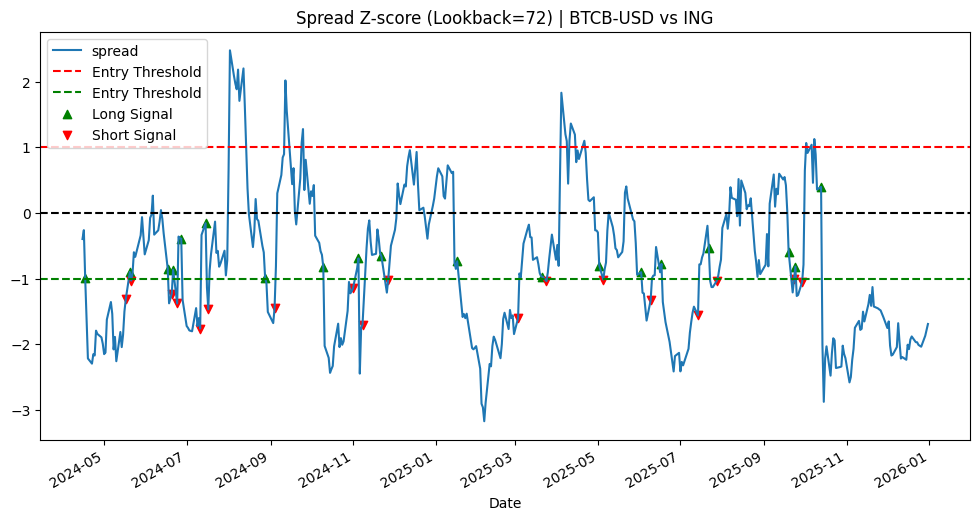


=== Pair BTCB-USD vs JPM ===


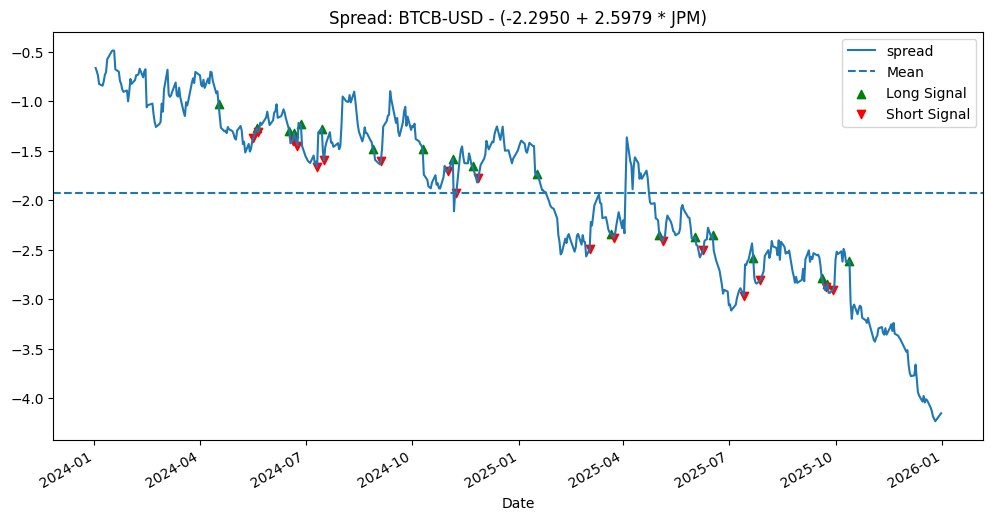

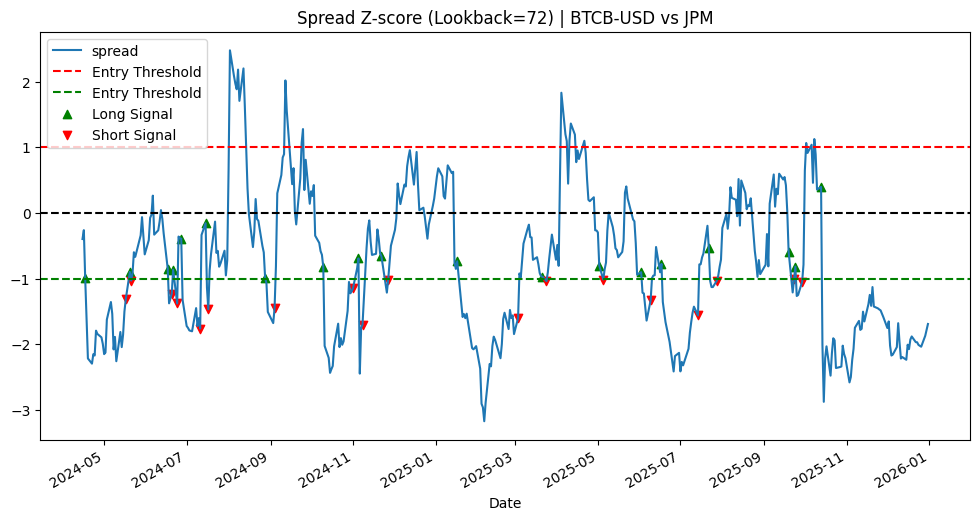


=== Pair DB vs DOGE-USD ===


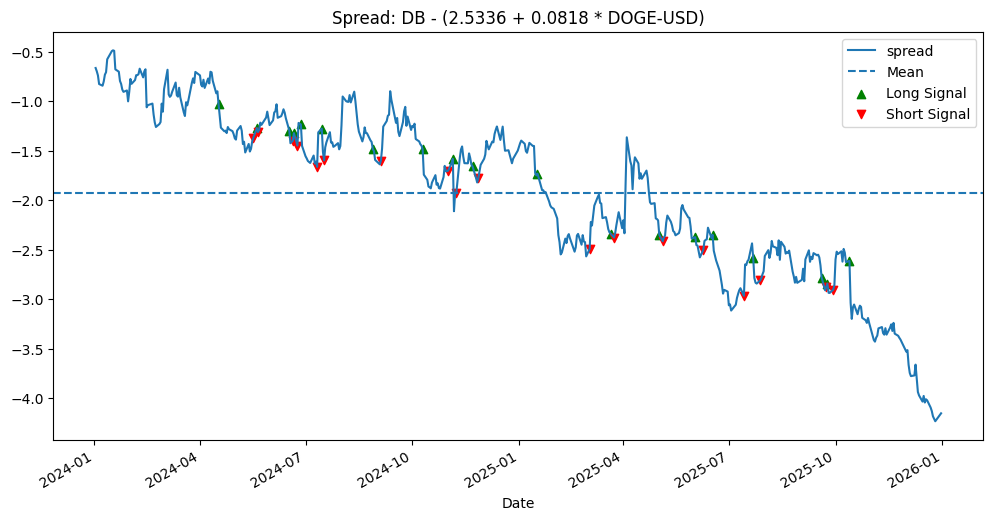

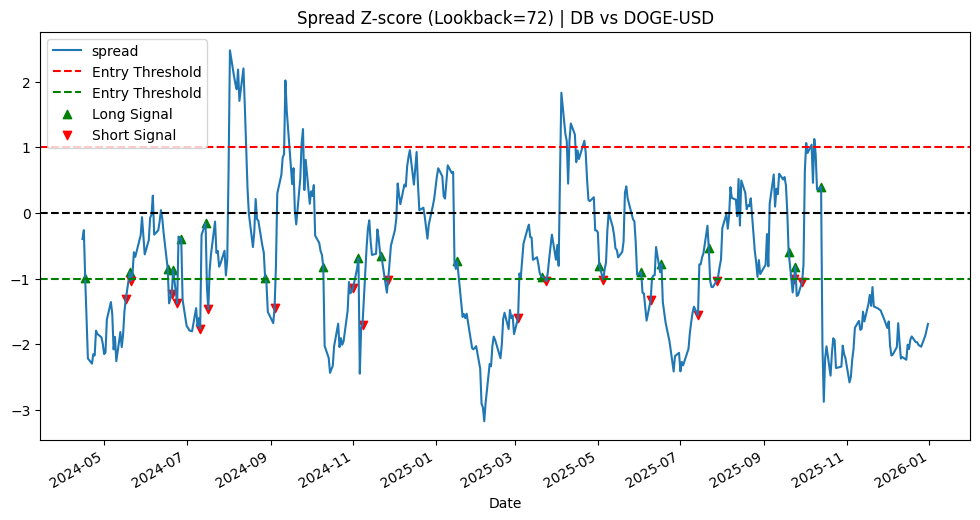


=== Pair DB vs GOOG ===


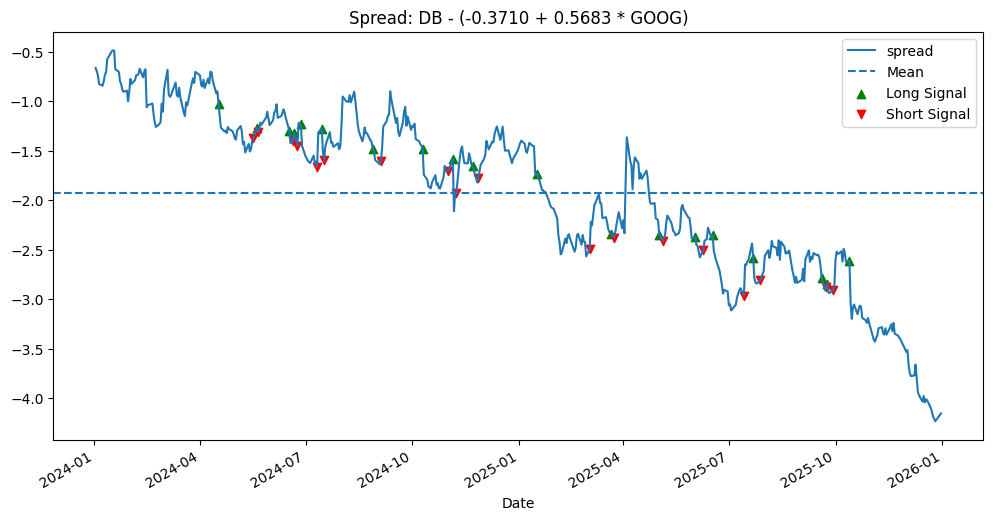

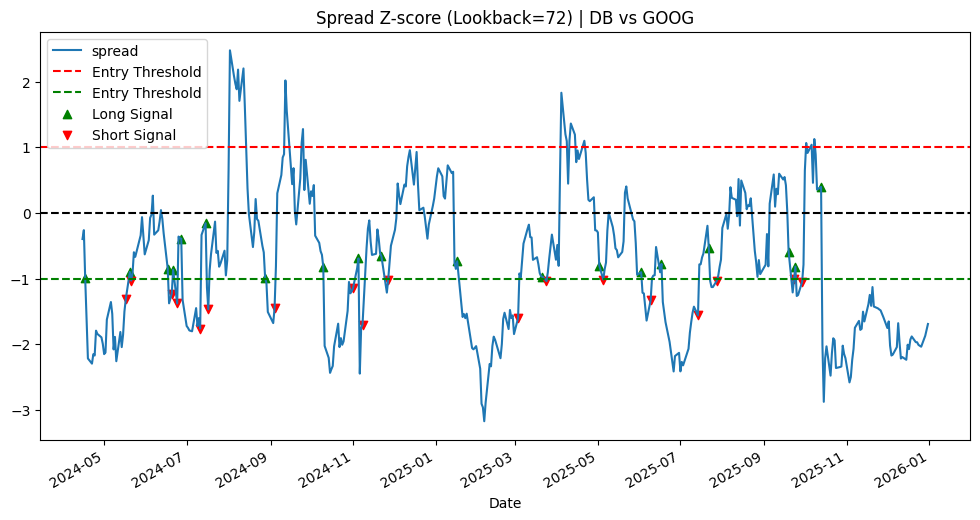


=== Pair DB vs ING ===


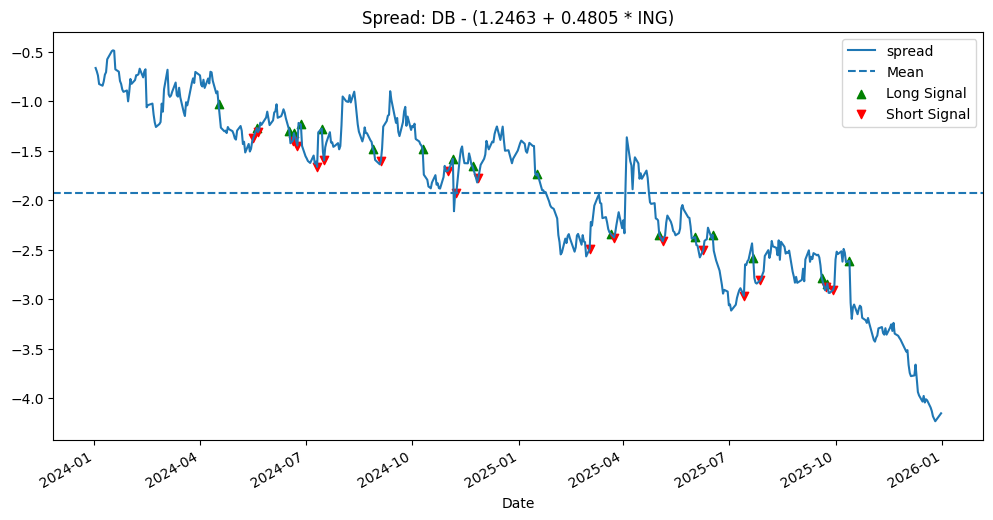

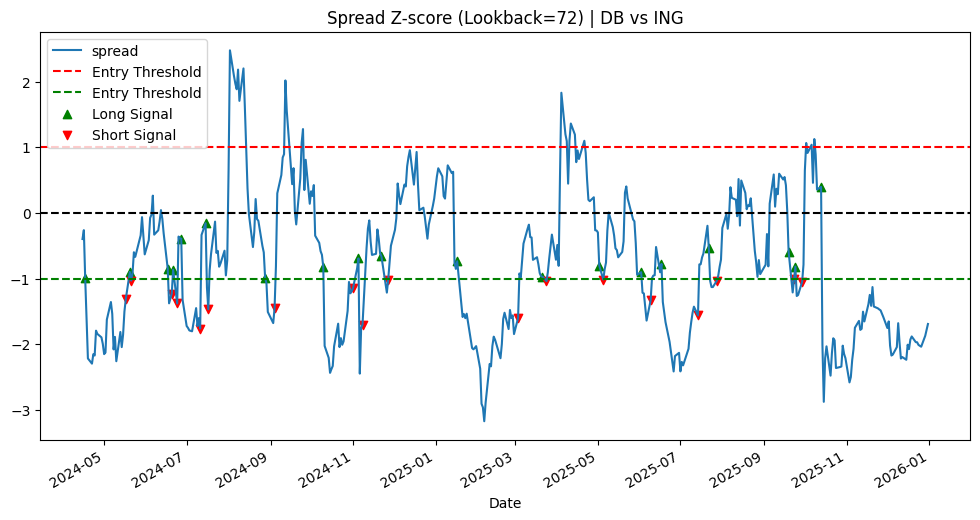


=== Pair DB vs JPM ===


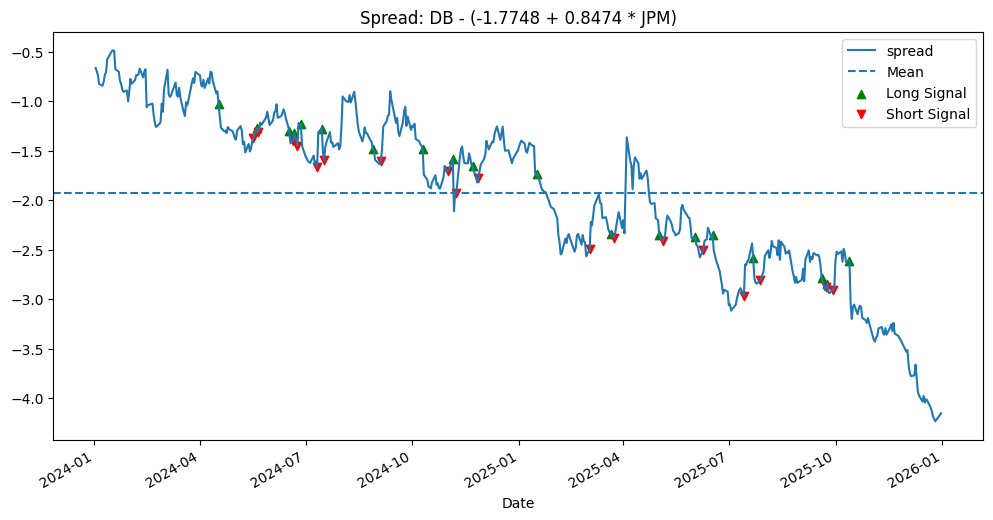

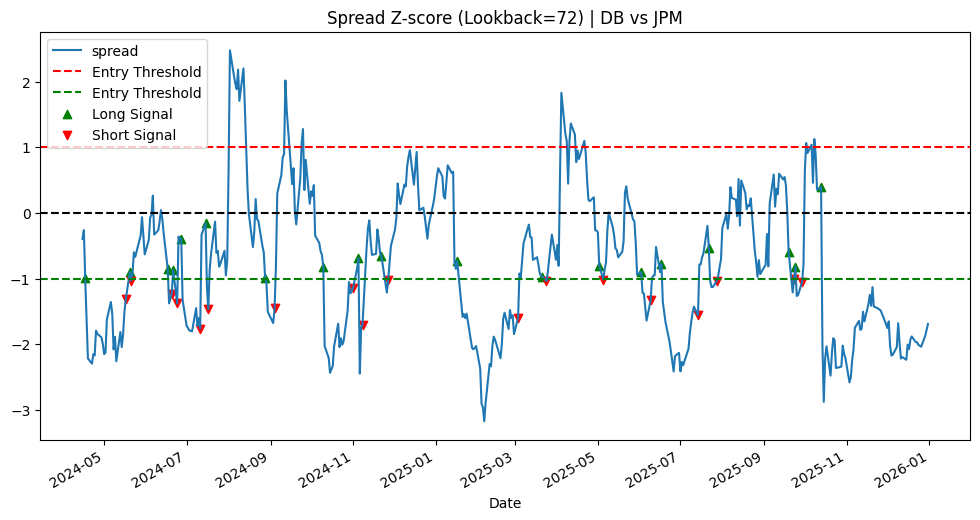


=== Pair DOGE-USD vs ING ===


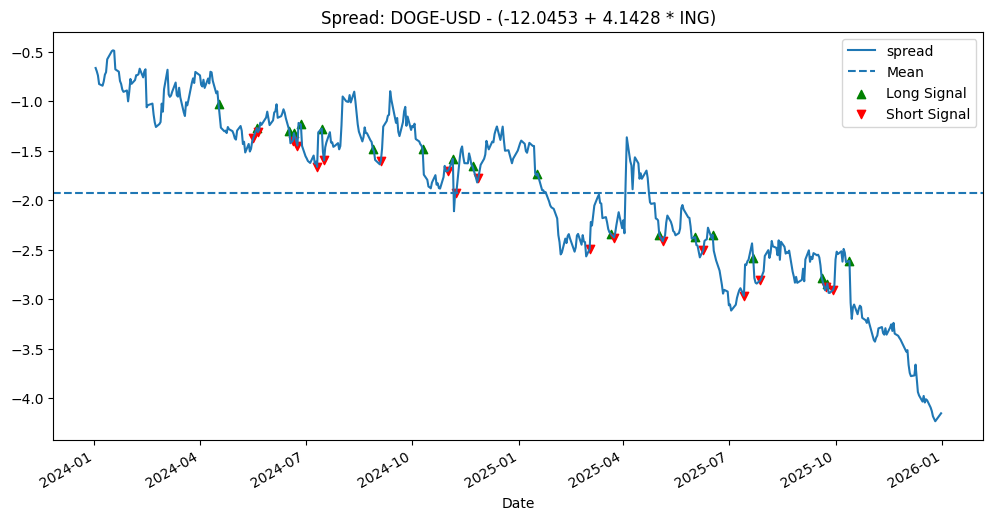

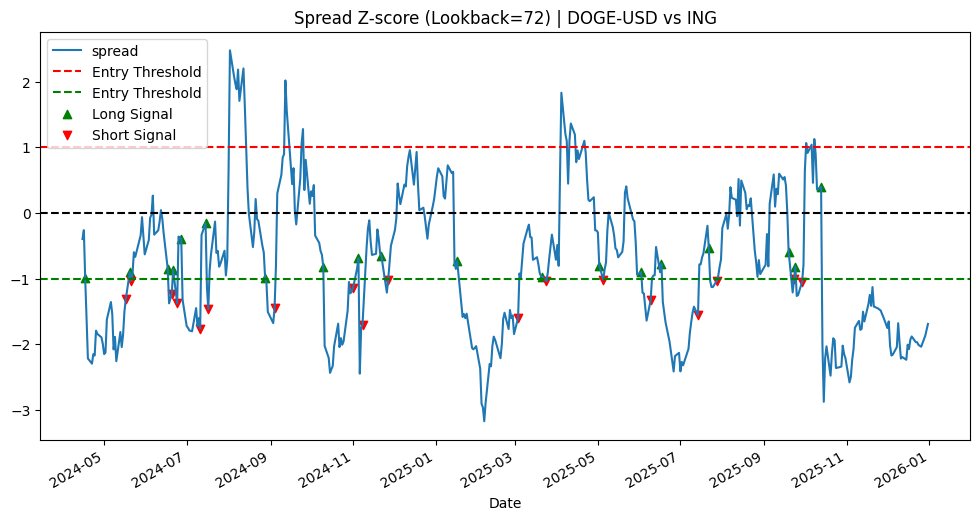


=== Pair DOGE-USD vs WFC ===


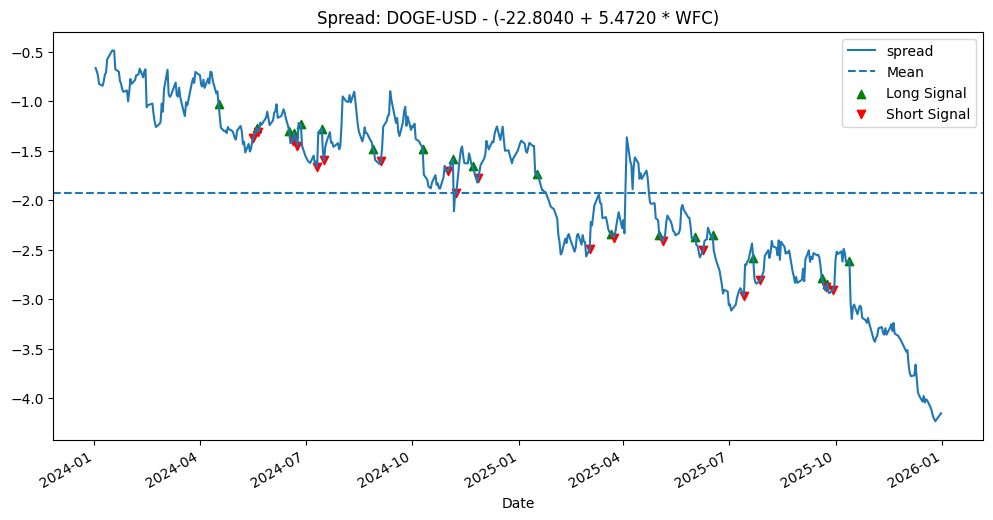

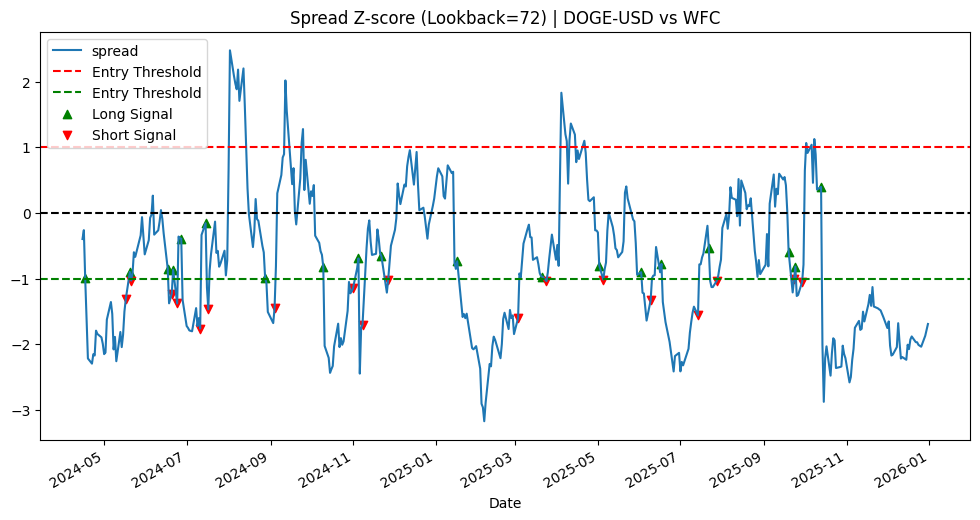

In [ ]:

TOP_N = 10  
Z_LOOKBACK = 72  
ENTRY_THRESHOLD = 1 
EXIT_THRESHOLD = 0  

for _, row in true_pairs.head(TOP_N).iterrows():
    y, x = row["y"], row["x"]
    
    print(f"\n=== Pair {y} vs {x} ===")
    try:
        alpha = fit_pair_model(maindata, y, x, use_log= True)['alpha']
        beta = fit_pair_model(maindata, y, x, use_log= True)['beta']
        spread = compute_spread_from_model(maindatatest,model )
        
        # Compute rolling z-score
        mu = spread.rolling(Z_LOOKBACK).mean()
        sd = spread.rolling(Z_LOOKBACK).std(ddof=0)
        z = (spread - mu) / sd

        # Plot spread, z-score and trading signals
        plot_signals_with_z(spread, z, alpha, beta,z_lookback=Z_LOOKBACK, entry_threshold=ENTRY_THRESHOLD, exit_threshold=EXIT_THRESHOLD)
        
    except Exception as e:
        print(f"Skipping {y} vs {x} due to error: {e}")



In [474]:
def simulate_trades(spread: pd.Series, z: pd.Series, entry_threshold=2, exit_threshold=0):
    """
    Simulate trades from spread and z-score.
    Signal is observed on day t-1 and executed on day t.
    Returns one row per completed trade.
    """
    spread = spread.dropna()
    z = z.dropna()

    common_index = spread.index.intersection(z.index)
    spread = spread.loc[common_index]
    z = z.loc[common_index]

    trades = []
    current_position = None
    entry_date = None
    entry_price = None

    for i in range(1, len(z)):
        prev_z = z.iloc[i - 1]   # yesterday's signal
        today_date = z.index[i]
        today_spread = spread.iloc[i]

        # Entry
        if current_position is None:
            if prev_z < -entry_threshold:
                current_position = "long"
                entry_date = today_date
                entry_price = today_spread

            elif prev_z > entry_threshold:
                current_position = "short"
                entry_date = today_date
                entry_price = today_spread

        # Exit
        elif current_position == "long":
            if prev_z >= exit_threshold:
                exit_date = today_date
                exit_price = today_spread
                pnl = exit_price - entry_price

                trades.append({
                    "entry_date": entry_date,
                    "exit_date": exit_date,
                    "entry_price": entry_price,
                    "exit_price": exit_price,
                    "position": current_position,
                    "P&L": pnl
                })

                current_position = None
                entry_date = None
                entry_price = None

        elif current_position == "short":
            if prev_z <= -exit_threshold:
                exit_date = today_date
                exit_price = today_spread
                pnl = entry_price - exit_price

                trades.append({
                    "entry_date": entry_date,
                    "exit_date": exit_date,
                    "entry_price": entry_price,
                    "exit_price": exit_price,
                    "position": current_position,
                    "P&L": pnl
                })

                current_position = None
                entry_date = None
                entry_price = None

    return pd.DataFrame(trades)

In [475]:
true_pairs

,y,x,n_obs,return_corr,alpha,beta,coint_p,spread_adf_p,half_life,suitable,fails
13,BTCB-USD,DB,1006,0.304746,4.498693,2.470239,0.043422,0.011290,33.599941,True,NaN
16,BTCB-USD,GOOG,1006,0.310394,0.241878,2.122439,0.069979,0.020090,35.565613,True,NaN
17,BTCB-USD,ING,1006,0.309513,7.229596,1.349920,0.077693,0.022745,58.024621,True,NaN
19,BTCB-USD,JPM,1006,0.284884,-2.294951,2.597907,0.031339,0.007447,27.629228,True,NaN
25,DB,DOGE-USD,1006,0.160447,2.533637,0.081827,0.048100,0.012918,35.942821,True,NaN
27,DB,GOOG,1006,0.366497,-0.370960,0.568310,0.016434,0.003654,35.975963,True,NaN
28,DB,ING,1006,0.768668,1.246299,0.480462,0.079498,0.023299,45.255220,True,NaN
30,DB,JPM,1006,0.659664,-1.774821,0.847389,0.015625,0.003442,28.876968,True,NaN
38,DOGE-USD,ING,1006,0.144059,-12.045283,4.142752,0.085873,0.024882,54.533357,True,NaN
44,DOGE-USD,WFC,1006,0.141315,-22.803970,5.471984,0.001555,0.000231,29.845486,True,NaN


In [476]:
maindatatest

,AMZN,ANTH.PVT,BTCB-USD,DB,DOGE-USD,ETC-USD,GOOG,ING,JEPI,JPM,KO,OPAI.PVT,PEP,UBS,WFC,XLM-USD
Date,,,,,,,,,,,,,,,,
2024-01-01,NaN,NaN,43985.078125,NaN,0.092024,22.500179,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.131905
2024-01-02,149.929993,56.480000,44971.941406,12.866043,0.091204,22.001184,138.423553,13.019940,46.884735,163.843567,56.383640,150.000000,159.680069,28.688696,47.037601,0.129287
2024-01-03,148.470001,56.480000,42810.136719,12.610803,0.082042,20.031158,139.217026,12.931728,46.621063,163.129471,56.515598,150.000000,159.716995,27.650618,46.417805,0.120552
2024-01-04,144.570007,56.480000,44268.085938,12.875497,0.084131,20.501585,136.915939,12.737664,46.604042,164.212006,56.327084,150.000000,158.350235,27.905416,46.989925,0.121644
2024-01-05,145.240005,56.480000,44130.425781,12.979484,0.082773,20.122894,136.271225,12.817054,46.570007,165.035934,56.242260,150.000000,156.013840,28.235716,47.600182,0.119129
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27,NaN,NaN,87687.250000,NaN,0.124224,12.211022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.220622
2025-12-28,NaN,NaN,87766.296875,NaN,0.123825,12.179569,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.220068
2025-12-29,232.070007,272.980011,87153.406250,38.619999,0.122730,11.916054,314.168701,27.950001,57.215641,322.296204,70.160004,499.279999,142.962769,46.549999,94.519997,0.215940


In [ ]:
# Loop through the true pairs to simulate trades for each pair
results = []

for _, row in true_pairs.iterrows(): 
    y, x = row["y"], row["x"]
    print(f"\nSimulating trades for pair: {y} vs {x}")
    
    model = fit_pair_model(maindata, y, x)
    # Compute spread and z-score
    spread = compute_spread_from_model(maindatatest, model)
    mu = spread.rolling(Z_LOOKBACK).mean().shift(1)
    sd = spread.rolling(Z_LOOKBACK).std(ddof=0).shift(1)
    z = (spread - mu) / sd
    
    # Simulate trades
    trades_df = simulate_trades(spread, z, entry_threshold=ENTRY_THRESHOLD, exit_threshold=EXIT_THRESHOLD)
    
    # Store results
    if not trades_df.empty:
        trades_df["pair"] = f"{y} vs {x}"
        results.append(trades_df)

# Concatenate results into one DataFrame
all_trades_df = pd.concat(results, ignore_index=True)


Simulating trades for pair: BTCB-USD vs DB

Simulating trades for pair: BTCB-USD vs GOOG

Simulating trades for pair: BTCB-USD vs ING

Simulating trades for pair: BTCB-USD vs JPM

Simulating trades for pair: DB vs DOGE-USD

Simulating trades for pair: DB vs GOOG

Simulating trades for pair: DB vs ING

Simulating trades for pair: DB vs JPM

Simulating trades for pair: DOGE-USD vs ING

Simulating trades for pair: DOGE-USD vs WFC

Simulating trades for pair: ETC-USD vs WFC

Simulating trades for pair: GOOG vs ING

Simulating trades for pair: GOOG vs JPM

Simulating trades for pair: GOOG vs WFC

Simulating trades for pair: KO vs PEP


In [478]:
all_trades_df

,entry_date,exit_date,entry_price,exit_price,position,P&L,pair
0,2024-04-18,2024-06-17,-0.119006,-0.143110,long,-0.024104,BTCB-USD vs DB
1,2024-07-02,2024-07-22,-0.307384,-0.299593,long,0.007790,BTCB-USD vs DB
2,2024-07-25,2024-08-20,-0.127359,-0.204711,short,0.077352,BTCB-USD vs DB
3,2024-08-28,2024-10-30,-0.335514,-0.203405,long,0.132110,BTCB-USD vs DB
4,2024-11-11,2025-01-16,-0.063895,-0.162138,short,0.098243,BTCB-USD vs DB
...,...,...,...,...,...,...,...
115,2024-05-30,2024-10-14,0.052717,0.154130,short,-0.101414,KO vs PEP
116,2024-10-28,2024-12-18,0.130664,0.151311,long,0.020647,KO vs PEP
117,2025-01-10,2025-07-03,0.188667,0.385745,short,-0.197078,KO vs PEP
118,2025-07-18,2025-11-03,0.317535,0.287702,long,-0.029833,KO vs PEP


In [479]:
def evaluate_strategy_performance(trades_df: pd.DataFrame):
    """
    Evaluate pair-level strategy performance.
    Expects trades_df to contain trades for exactly one pair.
    """
    if trades_df.empty:
        return None

    total_pnl = trades_df["P&L"].sum()

    wins = (trades_df["P&L"] > 0).sum()
    losses = (trades_df["P&L"] < 0).sum()
    win_loss_ratio = wins / losses if losses > 0 else np.inf

    durations = (trades_df["exit_date"] - trades_df["entry_date"]).dt.days
    avg_duration = durations.mean()

    trade_returns = trades_df["P&L"]
    sharpe_ratio = trade_returns.mean() / trade_returns.std(ddof=0) if trade_returns.std(ddof=0) != 0 else 0

    return {
        "pair": trades_df["pair"].iloc[0],
        "Total P&L": total_pnl,
        "Win/Loss Ratio": win_loss_ratio,
        "Avg Trade Duration (days)": avg_duration,
        "Sharpe Ratio": sharpe_ratio
    }


performance_results = []

for pair_name, pair_trades in all_trades_df.groupby("pair"):
    metrics = evaluate_strategy_performance(pair_trades)
    if metrics is not None:
        performance_results.append(metrics)

performance_df = pd.DataFrame(performance_results)
display(performance_df)

,pair,Total P&L,Win/Loss Ratio,Avg Trade Duration (days),Sharpe Ratio
0,BTCB-USD vs DB,-0.941874,2.000000,83.500000,-0.324189
1,BTCB-USD vs GOOG,-0.023402,1.500000,64.600000,-0.047609
2,BTCB-USD vs ING,-0.365578,2.000000,50.555556,-0.266367
3,BTCB-USD vs JPM,0.663188,4.500000,34.090909,0.402022
4,DB vs DOGE-USD,-0.255664,2.000000,58.222222,-0.203497
5,DB vs GOOG,-0.359066,2.000000,57.111111,-0.229202
6,DB vs ING,-0.317662,2.000000,56.666667,-0.326141
7,DB vs JPM,-0.178604,3.500000,49.444444,-0.160438
8,DOGE-USD vs ING,-3.617577,0.000000,170.000000,-3.097094
9,DOGE-USD vs WFC,4.698189,6.000000,27.785714,1.743090


In [ ]:
greedy_filter = (
    (performance_df["Win/Loss Ratio"] >= 3) &
    (performance_df["Sharpe Ratio"] > 0.3)
)

top_pairs_greedy = performance_df[greedy_filter].copy()

print("Greedy Portfolio Allocation:")
display(top_pairs_greedy)


Greedy Portfolio Allocation:


,pair,Total P&L,Win/Loss Ratio,Avg Trade Duration (days),Sharpe Ratio
3,BTCB-USD vs JPM,0.663188,4.5,34.090909,0.402022
9,DOGE-USD vs WFC,4.698189,6.0,27.785714,1.743090
13,GOOG vs WFC,0.291556,7.0,42.750000,1.322871


In [481]:
performance_df = performance_df.copy()

performance_df["composite_score"] = (
    performance_df["Win/Loss Ratio"] * 0.3
    + performance_df["Total P&L"] * 0.4
    + performance_df["Sharpe Ratio"] * 0.3
)

performance_df["portfolio_weight"] = (
    performance_df["composite_score"] / performance_df["composite_score"].sum()
)

capital = 100000
performance_df["capital_allocation"] = performance_df["portfolio_weight"] * capital

print("Diversified Portfolio Allocation:")
display(performance_df[["pair", "Total P&L", "portfolio_weight", "capital_allocation"]])

Diversified Portfolio Allocation:


,pair,Total P&L,portfolio_weight,capital_allocation
0,BTCB-USD vs DB,-0.941874,0.010799,1079.906635
1,BTCB-USD vs GOOG,-0.023402,0.036544,3654.352296
2,BTCB-USD vs ING,-0.365578,0.032044,3204.387589
3,BTCB-USD vs JPM,0.663188,0.148785,14878.450354
4,DB vs DOGE-USD,-0.255664,0.037429,3742.880926
5,DB vs GOOG,-0.359066,0.033223,3322.275482
6,DB vs ING,-0.317662,0.032150,3214.964263
7,DB vs JPM,-0.178604,0.079748,7974.799586
8,DOGE-USD vs ING,-3.617577,-0.203663,-20366.343456
9,DOGE-USD vs WFC,4.698189,0.360176,36017.582255


In [483]:
performance_df

,pair,Total P&L,Win/Loss Ratio,Avg Trade Duration (days),Sharpe Ratio,composite_score,portfolio_weight,capital_allocation
0,BTCB-USD vs DB,-0.941874,2.000000,83.500000,-0.324189,0.125994,0.010799,1079.906635
1,BTCB-USD vs GOOG,-0.023402,1.500000,64.600000,-0.047609,0.426356,0.036544,3654.352296
2,BTCB-USD vs ING,-0.365578,2.000000,50.555556,-0.266367,0.373859,0.032044,3204.387589
3,BTCB-USD vs JPM,0.663188,4.500000,34.090909,0.402022,1.735882,0.148785,14878.450354
4,DB vs DOGE-USD,-0.255664,2.000000,58.222222,-0.203497,0.436685,0.037429,3742.880926
5,DB vs GOOG,-0.359066,2.000000,57.111111,-0.229202,0.387613,0.033223,3322.275482
6,DB vs ING,-0.317662,2.000000,56.666667,-0.326141,0.375093,0.032150,3214.964263
7,DB vs JPM,-0.178604,3.500000,49.444444,-0.160438,0.930427,0.079748,7974.799586
8,DOGE-USD vs ING,-3.617577,0.000000,170.000000,-3.097094,-2.376159,-0.203663,-20366.343456
9,DOGE-USD vs WFC,4.698189,6.000000,27.785714,1.743090,4.202203,0.360176,36017.582255


In [ ]:
# Calculate the portfolio return for both strategies

# Greedy Strategy: All capital in top pairs
greedy_portfolio_return = top_pairs_greedy['Total P&L'].sum()  # Total P&L for the top pairs

# Diversified Strategy: Portfolio return based on allocation
diversified_portfolio_return = (performance_df['capital_allocation'] * performance_df['Total P&L']).sum()

# Compare returns
print(f"Greedy Portfolio Return: {greedy_portfolio_return:.2f}")
print(f"Diversified Portfolio Return: {diversified_portfolio_return:.2f}")

Greedy Portfolio Return: 5.65
Diversified Portfolio Return: 261112.35


In [ ]:
# Joint Greedy and diversified 

# Calculate a composite score for each pair (this is a weighted sum of the win/loss ratio, total P&L, and Sharpe ratio)
performance_df['composite_score'] = (performance_df['Win/Loss Ratio'] * 0.3) + (performance_df['Total P&L'] * 0.4) + (performance_df['Sharpe Ratio'] * 0.3)

# Normalize the composite scores so that they sum up to 1
performance_df['portfolio_weight'] = performance_df['composite_score'] / performance_df['composite_score'].sum()



# Assuming you start with $100,000 in capital, you can now allocate according to the portfolio weights
capital = 100000
performance_df['capital_allocation'] = performance_df['portfolio_weight'] * capital

greedy_filter = (performance_df['Win/Loss Ratio'] >= 3) & (performance_df['Sharpe Ratio'] > 0.3)

# Apply the filter to get the top performing pairs
top_pairs_greedyanddiversified = performance_df[greedy_filter]
capital = 100000
top_pairs_greedyanddiversified['capital_allocation'] = performance_df['portfolio_weight']*capital


In [486]:
top_pairs_greedyanddiversified

,pair,Total P&L,Win/Loss Ratio,Avg Trade Duration (days),Sharpe Ratio,composite_score,portfolio_weight,capital_allocation
3,BTCB-USD vs JPM,0.663188,4.5,34.090909,0.402022,1.735882,0.148785,14878.450354
9,DOGE-USD vs WFC,4.698189,6.0,27.785714,1.743090,4.202203,0.360176,36017.582255
13,GOOG vs WFC,0.291556,7.0,42.750000,1.322871,2.613484,0.224005,22400.480976


In [487]:
top_pairs_greedyanddiversified_return = (top_pairs_greedyanddiversified['capital_allocation'] * top_pairs_greedyanddiversified['Total P&L']).sum()
top_pairs_greedyanddiversified_return

np.float64(185615.60097929178)

In [488]:
top_pairs_greedy

,pair,Total P&L,Win/Loss Ratio,Avg Trade Duration (days),Sharpe Ratio
3,BTCB-USD vs JPM,0.663188,4.5,34.090909,0.402022
9,DOGE-USD vs WFC,4.698189,6.0,27.785714,1.743090
13,GOOG vs WFC,0.291556,7.0,42.750000,1.322871


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Portfolio Manager class
class PortfolioManager:
    def __init__(self, capital, valid_pairs, method='diversified'):
        """
        Initialize the Portfolio Manager with capital, valid pairs and the method (greedy/diversified).
        
        Parameters:
        capital (float): Initial capital to allocate.
        valid_pairs (pd.DataFrame): DataFrame of valid pairs with performance metrics (win/loss ratio, P&L, Sharpe ratio).
        method (str): Method to use ('greedy' or 'diversified').
        """
        self.capital = capital
        self.valid_pairs = valid_pairs
        self.method = method
        self.portfolio = None

    def create_portfolio(self):
        """
        Create the portfolio based on the chosen method (Greedy or Diversified).
        """
        if self.method == 'greedy':
            self.portfolio = self._create_greedy_portfolio()
        elif self.method == 'diversified':
            self.portfolio = self._create_diversified_portfolio()
        else:
            raise ValueError("Method must be either 'greedy' or 'diversified'")
        
        return self.portfolio

    def _create_greedy_portfolio(self):
        """
        Create a greedy portfolio by selecting the top-performing pairs based on performance metrics.
        """
        # Filter valid pairs based on high win/loss ratio, P&L, and Sharpe ratio
        greedy_filter = (self.valid_pairs['Win/Loss Ratio'] >= 3) & \
                        (self.valid_pairs['Sharpe Ratio'] > 0.3) 
                        

        top_pairs_greedy = self.valid_pairs[greedy_filter]
        
        # If there are no top pairs, raise an error
        if top_pairs_greedy.empty:
            raise ValueError("No valid pairs found for greedy portfolio.")
        
        # Allocate all capital to the top pairs
        top_pairs_greedy['capital_allocation'] = self.capital/ len(top_pairs_greedy)

        return top_pairs_greedy

    def _create_diversified_portfolio(self):
        """
        Create a diversified portfolio by allocating capital based on win/loss ratio, P&L, and Sharpe ratio.
        """
        # Calculate a composite score for each pair
        self.valid_pairs['composite_score'] = (self.valid_pairs['Win/Loss Ratio'] * 0.4) + \
                                               (self.valid_pairs['Total P&L'] * 0.4) + \
                                               (self.valid_pairs['Sharpe Ratio'] * 0.2)

        # Normalize the composite score so that total weight is 1
        self.valid_pairs['portfolio_weight'] = self.valid_pairs['composite_score'] / self.valid_pairs['composite_score'].sum()

        # Calculate the capital allocation for each pair
        self.valid_pairs['capital_allocation'] = self.valid_pairs['portfolio_weight'] * self.capital

        return self.valid_pairs

    def forecast_performance(self):
        """
        Forecast the portfolio performance based on the chosen portfolio and allocation.
        
        Returns:
        - total_portfolio_return (float): Forecasted total return of the portfolio.
        - average_sharpe_ratio (float): Average Sharpe ratio of the portfolio.
        """
        
        self.portfolio['forecasted_return'] = self.portfolio['capital_allocation'] * self.portfolio['Total P&L']
        
        # Total forecasted return of the portfolio
        total_portfolio_return = self.portfolio['forecasted_return'].sum()
        
        # Average Sharpe ratio of the portfolio
        average_sharpe_ratio = self.portfolio['Sharpe Ratio'].mean()
        
        return total_portfolio_return, average_sharpe_ratio

    def display_forecast(self):
        """
        Display the forecasted portfolio return and Sharpe ratio.
        """
        total_return, avg_sharpe = self.forecast_performance()
        
        print(f"Forecasted Total Portfolio Return: {total_return:.2f}")
        print(f"Forecasted Average Sharpe Ratio: {avg_sharpe:.2f}")

In [ ]:
valid_pairs = performance_df

capital = 100000  
method = 'greedy'  

portfolio_manager = PortfolioManager(capital, valid_pairs, method= 'diversified')

# Create portfolio
portfolio = portfolio_manager.create_portfolio()

# Display the forecasted portfolio performance
portfolio_manager.display_forecast()

Forecasted Total Portfolio Return: 198599.24
Forecasted Average Sharpe Ratio: -0.07
